<a href="https://colab.research.google.com/github/Buddha09/Interpretable-Classification-of-Time-series-using-Euler-Characteristic-Surfaces/blob/main/ECS_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS Time-Series Classification — Complete Pipeline

**Paper:** Interpretable Classification of Time Series Using Euler Characteristic Surfaces

This single notebook merges:
- **Main pipeline** (ECS construction, single-feature classifier, AdaBoost, STOMPE)
- **Ablation studies** (A1 ECC vs ECS, A2 K-sweep, B raw-window feature comparison)
- **Baseline comparison** (1-NN DTW, Shapelet Transform, ROCKET, MiniROCKET)

**Run order:** execute cells top to bottom. Each section is self-contained after Part 0–2.

---
### Table of Contents
- **Part 0** — Setup & Imports
- **Part 1** — Data Loading & Inspection
- **Part 2** — Core ECS Functions
- **Part 3** — ECS Visualisation (Time Series + 3D Surface + L1 Heatmap)
- **Part 4** — Helper Classifer Functions
- **Part 5** — Single-Feature Classifier (5-Fold CV + Test Evaluation)
- **Part 6** — AdaBoost Classifier (5-Fold CV + Test Evaluation + Alpha Heatmap)
- **Part 7** — Ablation Studies (A: Component Attribution | B: Raw vs Topological)
- **Part 8** — Baseline Comparison (1-NN DTW / STC / ROCKET / MiniROCKET)

## Part 0 — Setup & Imports

In [1]:
# Install required packages (run once on Colab)
!pip install gudhi aeon numba imbalanced-learn -q

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from collections import Counter

from numba import njit
from gudhi import AlphaComplex
from scipy.interpolate import griddata

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from aeon.datasets import load_classification

# ------------------------------------------------------------------
# Global publication-ready style (journal quality, dpi=600)
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.family"     : "serif",
    "font.size"       : 12,
    "axes.labelsize"  : 13,
    "axes.titlesize"  : 13,
    "xtick.labelsize" : 11,
    "ytick.labelsize" : 11,
    "legend.fontsize" : 11,
    "axes.linewidth"  : 1.2,
    "xtick.direction" : "in",
    "ytick.direction" : "in",
    "xtick.top"       : True,
    "ytick.right"     : True,
    "legend.frameon"  : False,
})

print("All imports successful.")

All imports successful.


## Part 1 — Data Loading & Inspection

### 1.1 — Dataset Configuration

Set `Dataset_name` and parameters here. All downstream cells use these variables.

In [3]:
# ============================================================
# Dataset configuration — change these to switch datasets
# ============================================================
Dataset_name    = "ECG5000"   # options: "ECG5000", "TwoLeadECG",
                               #          "ECG200", "ECGFiveDays",
                               #          "EpilepticSeizures"
REQUIRED_LENGTH = 140          # ECG5000=140, Epilepsy2=178, TwoLeadECG=82,
                               # ECG200=96, ECGFiveDays=136
DIM             = 3            # embedding dimension (FNN-selected)
DELAY           = 1            # time delay tau
SCALE_MAX       = 1.00         # upper bound of the filtration scale axis "TwoLeadECG",
                               #          "ECG200", 3.5 for "ECGFiveDays",
                               #          0.150 for "EpilepticSeizures"
WINDOW_VIZ      = 10           # K used for visualisation figures

### 1.2 — Load via `aeon` (automatic download from UCR archive)

In [4]:
# ------------------------------------------------------------------
# Option A: Load via aeon (requires internet — downloads from UCR)
# ------------------------------------------------------------------
X_train, y_train = load_classification(Dataset_name, split="train")
X_test,  y_test  = load_classification(Dataset_name, split="test")

print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
print(f"Train labels: {np.unique(y_train)}")
print(f"Test  labels: {np.unique(y_test)}")

# Class population counts
unique_labels = np.unique(y_train)
train_counts  = Counter(y_train)
test_counts   = Counter(y_test)

print("\n=== Class Population Counts ===")
print("TRAIN:")
for cls, count in sorted(train_counts.items()):
    print(f"  Class {cls}: {count}")
print("TEST:")
for cls, count in sorted(test_counts.items()):
    print(f"  Class {cls}: {count}")

# Time-series length & NaN audit
lengths = np.array([X_train[i].size for i in range(len(X_train))])
print(f"\nTime-series length  min={lengths.min()}  max={lengths.max()}  mean={lengths.mean():.1f}")

n_nan = sum(not np.isfinite(X_train[i]).all() for i in range(len(X_train)))
print(f"Samples with NaN/Inf in train: {n_nan}")

# Value range per class
print("\nAmplitude range per class (train):")
for label in unique_labels:
    subset = X_train[y_train == label]
    print(f"  Class {label}: min={np.min(subset):.4f}  max={np.max(subset):.4f}")

Train shape : (500, 1, 140)
Test  shape : (4500, 1, 140)
Train labels: ['1' '2' '3' '4' '5']
Test  labels: ['1' '2' '3' '4' '5']

=== Class Population Counts ===
TRAIN:
  Class 1: 292
  Class 2: 177
  Class 3: 10
  Class 4: 19
  Class 5: 2
TEST:
  Class 1: 2627
  Class 2: 1590
  Class 3: 86
  Class 4: 175
  Class 5: 22

Time-series length  min=140  max=140  mean=140.0
Samples with NaN/Inf in train: 0

Amplitude range per class (train):
  Class 1: min=-5.3757  max=4.0581
  Class 2: min=-5.2489  max=3.0456
  Class 3: min=-5.7976  max=2.2917
  Class 4: min=-5.6395  max=2.9597
  Class 5: min=-3.6506  max=2.1474


### 1.3 — Load from local `.ts` files (Colab upload / offline)

Use this cell instead of 1.2 when working offline or if aeon download fails.

In [5]:
# ------------------------------------------------------------------
# Option B: Load from local .ts files (upload to Colab or use path)
# Handles both standard UCR format and 'value:label' format.
# ------------------------------------------------------------------
def load_ts_file(filepath):
    """
    Parser for UCR/UEA .ts format.
    Handles labels appended as 'float_value:class_label'.
    """
    X, y = [], []
    in_data = False
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if line.lower() == "@data":
                in_data = True
                continue
            if line.lower().startswith("@"):
                continue
            if in_data and line:
                parts = line.split(",")
                last = parts[-1].strip()
                if ":" in last:
                    val_str, label = last.rsplit(":", 1)
                    parts[-1] = val_str
                else:
                    label = last
                    parts = parts[:-1]
                values = np.array([float(v) for v in parts])
                X.append(values)
                y.append(label.strip())
    return np.array(X)[:, np.newaxis, :], np.array(y)   # shape: (N, 1, L)


# Uncomment and set paths to use local files:
# TRAIN_PATH = r"/content/ECG5000_TRAIN.ts"
# TEST_PATH  = r"/content/ECG5000_TEST.ts"
# X_train, y_train = load_ts_file(TRAIN_PATH)
# X_test,  y_test  = load_ts_file(TEST_PATH)
# print(f"Loaded from file: Train {X_train.shape}  Test {X_test.shape}")

### 1.4 — Signal visualisation (one representative per class)

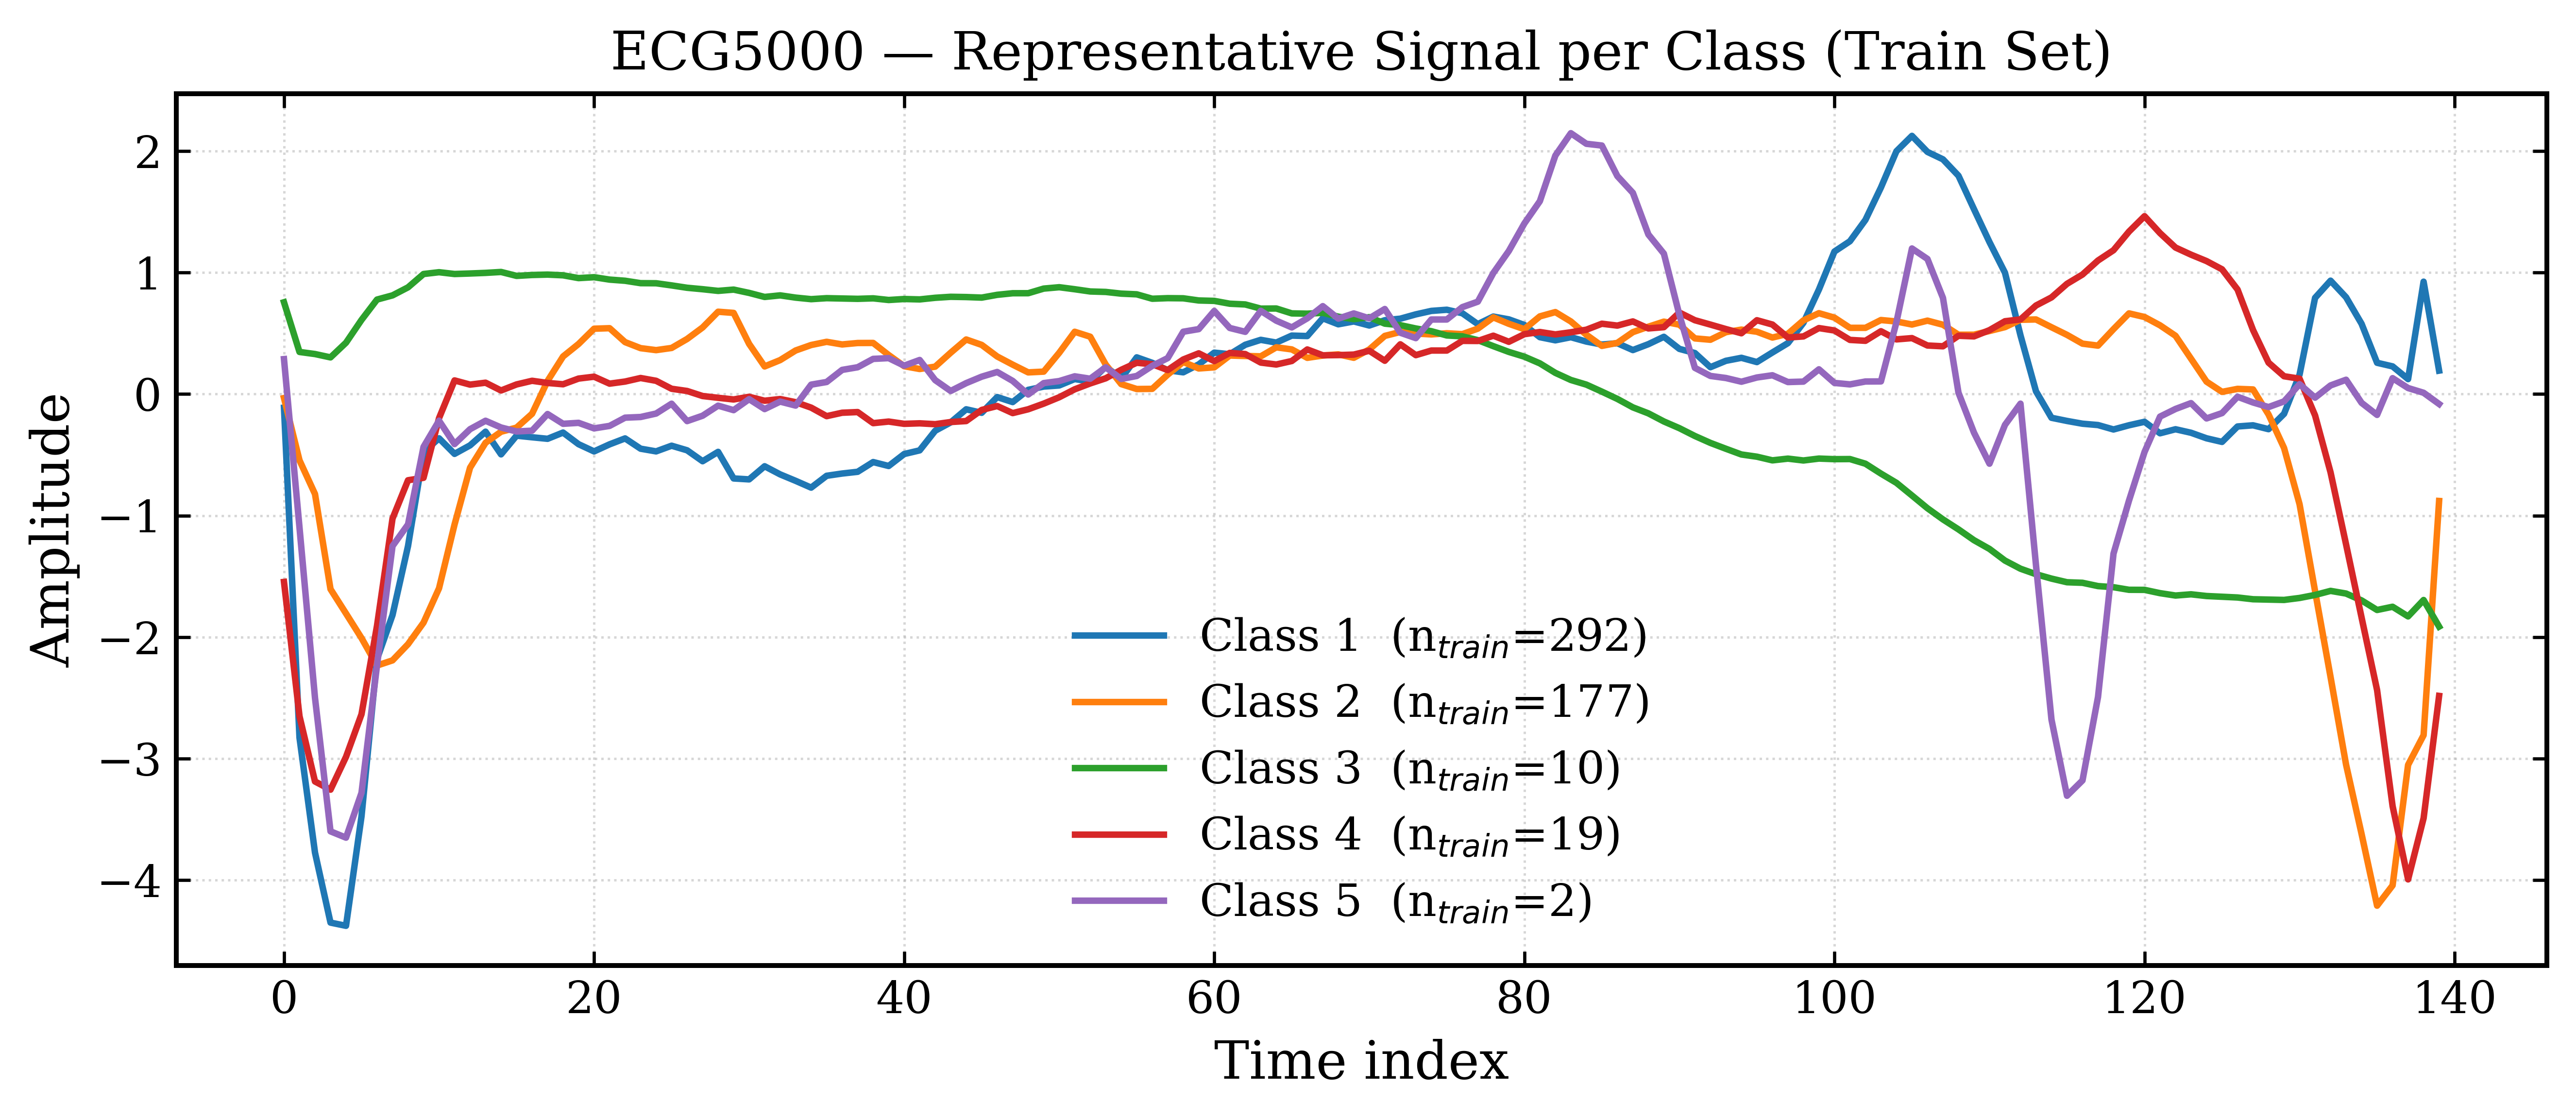

In [6]:
# ------------------------------------------------------------------
# Publication figure: one representative signal per class
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4), dpi=600)

colors = plt.cm.tab10.colors
for k, label in enumerate(unique_labels):
    idx = np.where(y_train == label)[0][0]
    ts  = np.asarray(X_train[idx][0], dtype=float)
    ax.plot(ts, color=colors[k % 10], lw=1.6,
            label=f"Class {label}  (n$_{{train}}$={train_counts[label]})")

ax.set_xlabel("Time index")
ax.set_ylabel("Amplitude")
ax.set_title(f"{Dataset_name} — Representative Signal per Class (Train Set)")
ax.legend()
ax.grid(True, ls=":", lw=0.6, alpha=0.5)
fig.tight_layout()
fig.savefig(f"{Dataset_name}_signals.pdf", dpi=600, bbox_inches="tight")
plt.show()

### 1.5 — Filter to exact length and select binary classes

In [7]:
# ------------------------------------------------------------------
# Filter by exact length and remove NaN/Inf
# ------------------------------------------------------------------
def filter_by_exact_length(X, y, length):
    X = np.asarray(X)
    y = np.asarray(y)
    keep = [i for i in range(len(X))
            if X[i].size == length and np.isfinite(X[i]).all()]
    return X[keep], y[keep]

X_tr_clean, y_tr_clean = filter_by_exact_length(X_train, y_train, REQUIRED_LENGTH)
X_te_clean, y_te_clean = filter_by_exact_length(X_test,  y_test,  REQUIRED_LENGTH)

print(f"Cleaned train: {len(X_tr_clean)} samples")
print(f"Cleaned test : {len(X_te_clean)} samples")

# ------------------------------------------------------------------
# Select two binary classes
# ECG5000: classes 1 & 2 (normal sinus vs R-on-T PVC)
# Epilepsy2: classes 1 (seizure) vs 2,3,4,5 merged
# Other datasets: first two classes by default
# ------------------------------------------------------------------
classes = sorted(np.unique(y_tr_clean))[0:2]   # adjust index for other datasets
print(f"\nSelecting binary classes: {classes}")

mask_tr = np.isin(y_tr_clean, classes)
mask_te = np.isin(y_te_clean, classes)

X_tr, y_tr = X_tr_clean[mask_tr], y_tr_clean[mask_tr]
X_te, y_te = X_te_clean[mask_te], y_te_clean[mask_te]

labels   = sorted(np.unique(y_tr))
y_bin_tr = (y_tr == labels[1]).astype(int)
y_bin_te = (y_te == labels[1]).astype(int)

print(f"Final training set : {X_tr.shape}   positives={y_bin_tr.sum()}")
print(f"Final testing  set : {X_te.shape}   positives={y_bin_te.sum()}")

Cleaned train: 500 samples
Cleaned test : 4500 samples

Selecting binary classes: [np.str_('1'), np.str_('2')]
Final training set : (469, 1, 140)   positives=177
Final testing  set : (4217, 1, 140)   positives=1590


## Part 2 — Core ECS Functions

These functions are identical across all experiments. Define once, use everywhere.

In [8]:
# ============================================================
# Numba-accelerated Takens delay embedding
# ============================================================
@njit
def takens_embed_numba(ts, dim, delay):
    """
    Embed scalar time series ts into R^dim using delay coordinates.
    Returns array of shape (L - (dim-1)*delay, dim).
    """
    L = ts.shape[0]
    M = L - (dim - 1) * delay
    if M <= 0:
        return np.empty((0, dim), dtype=np.float64)
    out = np.empty((M, dim), dtype=np.float64)
    for k in range(dim):
        start = k * delay
        for i in range(M):
            out[i, k] = ts[start + i]
    return out


# ============================================================
# Numba-accelerated Euler characteristic curve
# gudhi AlphaComplex filtration value = squared circumradius,
# so simplex enters at filtration scale r when filt_val <= r^2.
# chi(r) = sum_{simplices with filt_val <= r^2} (-1)^dim
# ============================================================
@njit
def compute_chi_curve_numba(f_vals, f_dims, scales):
    """
    Compute Euler characteristic chi at each filtration scale.
    f_vals : filtration values (squared circumradii from gudhi).
    f_dims : simplex dimensions.
    scales : 1-D array of filtration scale values r.
    Returns chi values as int64 array.
    """
    n      = f_vals.shape[0]
    m      = scales.shape[0]
    out    = np.empty(m, dtype=np.int64)
    order  = np.argsort(f_vals)
    s_vals = f_vals[order]
    s_dims = f_dims[order]
    chi    = 0
    ptr    = 0
    for i in range(m):
        thr = scales[i] * scales[i]
        while ptr < n and s_vals[ptr] <= thr:
            if (s_dims[ptr] % 2) == 0:
                chi += 1
            else:
                chi -= 1
            ptr += 1
        out[i] = chi
    return out


# ============================================================
# ECS feature vector for a single sample (K-window method)
# Returns flattened (window x window) grid.
# ============================================================
def ecs_grid_for_sample(ts, window, dim, delay, scale_max, required_length):
    """
    Compute the ECS feature vector (window x window flattened) for one sample.
    Uses K non-overlapping windows on the Takens point cloud.
    Griddata interpolation fills the (scale, window) 2-D grid.
    """
    ts_flat   = np.asarray(ts, dtype=float).flatten()
    pc        = takens_embed_numba(ts_flat, dim, delay)
    total_pts = pc.shape[0]
    # Ceiling division: add 1 only when not exactly divisible
    step      = total_pts // window + (1 if total_pts % window != 0 else 0)
    scales    = np.linspace(1e-20, scale_max, window)

    if total_pts < 3:
        return np.zeros(window * window), scales

    x_v, y_v, z_v = [], [], []

    for block_id in range(window):
        start = block_id * step
        end   = total_pts if block_id == window - 1 else start + step
        block = pc[start:end]

        if block.shape[0] < 3:
            continue

        st   = AlphaComplex(points=block.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if not filt:
            vals = np.array([0.0]); dims = np.array([0])
        else:
            vals = np.array([f[1]        for f in filt])
            dims = np.array([len(f[0])-1 for f in filt])

        chi = compute_chi_curve_numba(vals, dims, scales)
        for sc, c in zip(scales, chi):
            x_v.append(sc); y_v.append(block_id); z_v.append(c)

    if len(x_v) < 1:
        return np.zeros(window * window), scales

    xi = np.linspace(min(x_v), max(x_v), window)
    yi = np.linspace(0, window - 1, window)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x_v, y_v), z_v, (XI, YI), method="linear")
    ZI[np.isnan(ZI)] = griddata(
        (x_v, y_v), z_v, (XI, YI), method="nearest")[np.isnan(ZI)]

    return ZI.flatten(), scales


def build_feature_matrix(X, window, dim, delay, scale_max, required_length):
    """Build (N_samples, window^2) ECS feature matrix."""
    print(f"  Processing {len(X)} samples  (window={window}) ...")
    feats = []
    for x in X:
        f, _ = ecs_grid_for_sample(x, window, dim, delay, scale_max, required_length)
        feats.append(f)
    return np.vstack(feats)


# ============================================================
# ECC (K=1) feature matrix — used for ablation A1
# No temporal windowing: entire Takens point cloud in one block.
# Returns (N_samples, n_scales) chi values.
# ============================================================
def ecc_feature_matrix(X, dim, delay, scale_max, n_scales=20):
    """
    Compute the Euler Characteristic Curve (ECC) for each sample.
    No temporal windowing — the entire Takens point cloud is used.
    Returns shape (N_samples, n_scales): chi at each filtration scale.
    """
    scales = np.linspace(1e-20, scale_max, n_scales)
    rows   = []
    for x in X:
        ts_flat = np.asarray(x, dtype=float).flatten()
        pc      = takens_embed_numba(ts_flat, dim, delay)

        if pc.shape[0] < dim + 1:
            rows.append(np.zeros(n_scales))
            continue

        st   = AlphaComplex(points=pc.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if not filt:
            rows.append(np.zeros(n_scales))
            continue

        vals = np.array([f[1]        for f in filt])
        dims = np.array([len(f[0])-1 for f in filt])
        chi  = compute_chi_curve_numba(vals, dims, scales)
        rows.append(chi.astype(float))

    return np.vstack(rows)


print("Core ECS functions defined.")

Core ECS functions defined.


## Part 3 — ECS Visualisation

### 3.1 — Select representative signals

In [9]:
# ------------------------------------------------------------------
# Pick one representative per class for visualisation
# ------------------------------------------------------------------
ts1 = np.asarray(X_tr[y_bin_tr == 0][0], dtype=float).flatten()
ts2 = np.asarray(X_tr[y_bin_tr == 1][0], dtype=float).flatten()
print(f"Class {labels[0]} signal length: {len(ts1)}")
print(f"Class {labels[1]} signal length: {len(ts2)}")

Class 1 signal length: 140
Class 2 signal length: 140


### 3.2 — Build ECS scatter (window-index axis)

In [10]:
# ------------------------------------------------------------------
# Build ECS scatter using window index k on y-axis
# ------------------------------------------------------------------
def build_ecs_scatter_windowed(ts, dim, delay, window, scale_max):
    ts_flat   = np.asarray(ts, dtype=float).flatten()
    pc        = takens_embed_numba(ts_flat, dim, delay)
    total_pts = pc.shape[0]
    step      = total_pts // window + (1 if total_pts % window != 0 else 0)
    scales    = np.linspace(1e-30, scale_max, window)

    x_vals, y_vals, z_vals = [], [], []

    for block_id in range(window):
        start = block_id * step
        end   = total_pts if block_id == window - 1 else start + step
        block = pc[start:end]

        if block.shape[0] < 3:
            continue

        st   = AlphaComplex(points=block.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if not filt:
            vals = np.array([0.0]); dims = np.array([0])
        else:
            vals = np.array([f[1]          for f in filt])
            dims = np.array([len(f[0]) - 1 for f in filt])

        chi = compute_chi_curve_numba(vals, dims, scales)

        for sc, c in zip(scales, chi):
            x_vals.append(sc)
            y_vals.append(block_id + 1)   # k = 1, 2, ..., window
            z_vals.append(c)

    return np.array(x_vals), np.array(y_vals), np.array(z_vals), scales


def ecs_to_grid_k(x, y, z, nx, ny):
    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(1, ny, ny)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x, y), z, (XI, YI), method="linear")
    ZI = np.where(np.isnan(ZI),
                  griddata((x, y), z, (XI, YI), method="nearest"),
                  ZI)
    return XI, YI, ZI


# Compute grids
xv1k, yv1k, zv1k, sc1k = build_ecs_scatter_windowed(
    ts1, DIM, DELAY, WINDOW_VIZ, SCALE_MAX)
xv2k, yv2k, zv2k, sc2k = build_ecs_scatter_windowed(
    ts2, DIM, DELAY, WINDOW_VIZ, SCALE_MAX)

XI1k, YI1k, ZI1k = ecs_to_grid_k(xv1k, yv1k, zv1k, WINDOW_VIZ, WINDOW_VIZ)
XI2k, YI2k, ZI2k = ecs_to_grid_k(xv2k, yv2k, zv2k, WINDOW_VIZ, WINDOW_VIZ)

print("ECS grids computed.")

ECS grids computed.


### 3.3 — 2×2 publication figure (time series + 3D ECS surface)

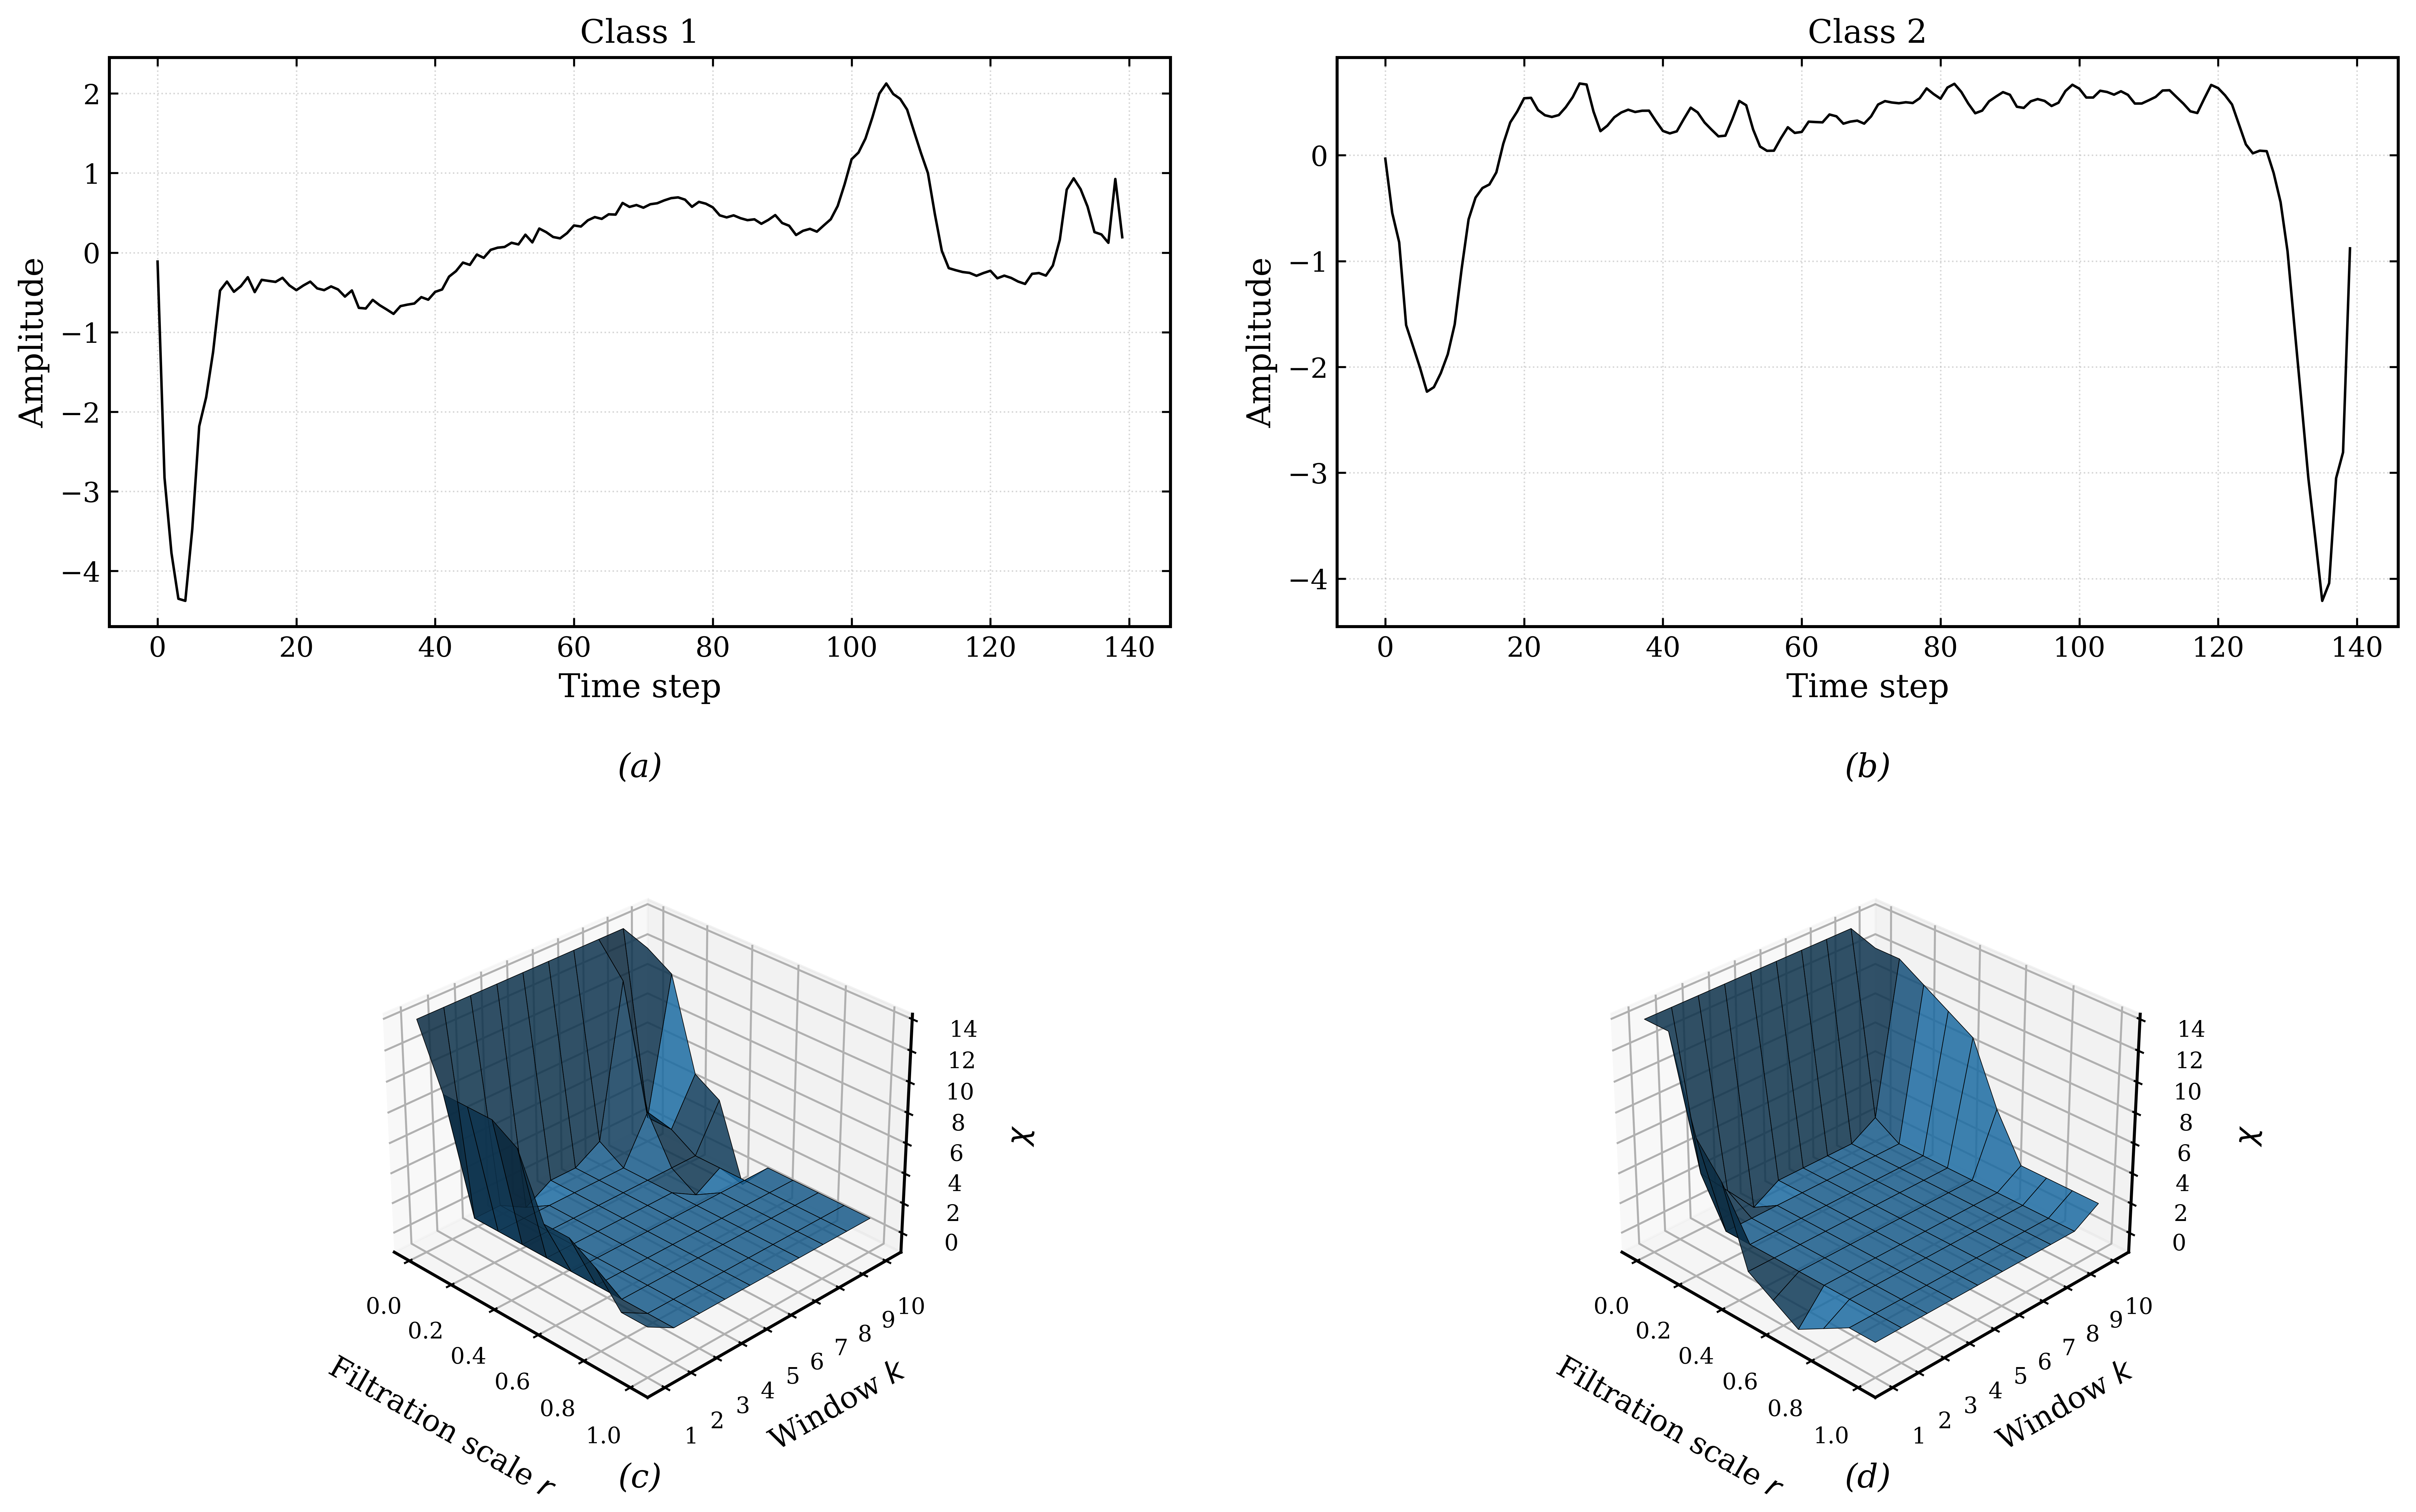

Figure saved.


In [11]:
# ------------------------------------------------------------------
# 3D surface helper
# ------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FixedLocator, FixedFormatter, MaxNLocator

def plot_ecs_k_axis(ax3d, XI, YI, ZI, window, scales):
    ax3d.plot_surface(
        XI, YI, ZI,
        linewidth=0.25, edgecolor="black",
        antialiased=True, alpha=0.85, shade=True,
    )
    ax3d.view_init(elev=30, azim=-45)
    ax3d.set_xlabel(r"Filtration scale $r$", labelpad=12, fontsize=12)
    ax3d.set_ylabel(r"Window $k$",           labelpad=5,  fontsize=12)
    ax3d.set_zlabel(r"$\chi$",               labelpad=5,  fontsize=12)
    ax3d.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax3d.tick_params(labelsize=9)

# ------------------------------------------------------------------
# Publication figure: 2 x 2
# ------------------------------------------------------------------
label_offset = -0.22
label_kw     = dict(ha="center", va="top", fontsize=13, fontstyle="italic")

fig = plt.figure(figsize=(14, 9), dpi=600)

# (a) Time series — class 0
ax_a = fig.add_subplot(2, 2, 1)
ax_a.plot(ts1, color="black", lw=1.0)
ax_a.set_xlabel("Time step"); ax_a.set_ylabel("Amplitude")
ax_a.set_title(f"Class {labels[0]}")
ax_a.tick_params(direction="in")
ax_a.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_a.text(0.5, label_offset, "(a)", transform=ax_a.transAxes, **label_kw)

# (b) Time series — class 1
ax_b = fig.add_subplot(2, 2, 2)
ax_b.plot(ts2, color="black", lw=1.0)
ax_b.set_xlabel("Time step"); ax_b.set_ylabel("Amplitude")
ax_b.set_title(f"Class {labels[1]}")
ax_b.tick_params(direction="in")
ax_b.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_b.text(0.5, label_offset, "(b)", transform=ax_b.transAxes, **label_kw)

# (c) 3D ECS surface — class 0
ax_c = fig.add_subplot(2, 2, 3, projection="3d")
plot_ecs_k_axis(ax_c, XI1k, YI1k, ZI1k, WINDOW_VIZ, sc1k)
ax_c.set_title(f"")
ax_c.text2D(0.5, -0.06, "(c)", transform=ax_c.transAxes, **label_kw)

# (d) 3D ECS surface — class 1
ax_d = fig.add_subplot(2, 2, 4, projection="3d")
plot_ecs_k_axis(ax_d, XI2k, YI2k, ZI2k, WINDOW_VIZ, sc2k)
ax_d.set_title(f"")
ax_d.text2D(0.5, -0.06, "(d)", transform=ax_d.transAxes, **label_kw)

fig.tight_layout(pad=2.5)
fig.savefig(f"{Dataset_name}_ts_and_ecs.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 3.4 — ECS difference heatmap and pairwise L1 distance matrix

In [12]:
# ============================================================
# ECS difference heatmap + pairwise L1 distance
# ============================================================
WINDOW_ANALYSIS = WINDOW_VIZ
SCALES_A        = np.linspace(1e-30, SCALE_MAX, WINDOW_ANALYSIS)

def ecs_flat_for_sample(ts, dim, delay, window, scale_max):
    """Return a flattened (window x window) ECS grid for one sample."""
    xv, yv, zv, sc = build_ecs_scatter_windowed(ts, dim, delay, window, scale_max)
    XI, YI, ZI     = ecs_to_grid_k(xv, yv, zv, window, window)
    return ZI.flatten(), sc

print(f"Building ECS feature matrix  (window={WINDOW_ANALYSIS}) ...")
feats, scs = [], []
for x in X_tr:
    f, sc = ecs_flat_for_sample(x, DIM, DELAY, WINDOW_ANALYSIS, SCALE_MAX)
    feats.append(f); scs.append(sc)

Z  = np.vstack(feats)          # (N_samples, WINDOW^2)
sc = scs[0]

mask0 = (y_tr == labels[0])
mask1 = (y_tr == labels[1])

mean0 = Z[mask0].mean(axis=0).reshape(WINDOW_ANALYSIS, WINDOW_ANALYSIS)
mean1 = Z[mask1].mean(axis=0).reshape(WINDOW_ANALYSIS, WINDOW_ANALYSIS)
diff  = np.abs(mean0 - mean1)

k_vals = np.arange(1, WINDOW_ANALYSIS + 1)
r_vals = sc
KK, RR = np.meshgrid(k_vals, r_vals, indexing="ij")

sort_idx = np.argsort(y_tr)
Z_sorted = Z[sort_idx]
y_sorted = y_tr[sort_idx]

N = Z_sorted.shape[0]
dr = (sc.max() - sc.min()) / (WINDOW_ANALYSIS - 1)
dk = 1.0

print(f"Computing pairwise L1 distances for {N} samples ...")
DM = np.zeros((N, N))
for i in range(N):
    for j in range(i + 1, N):
        d = np.sum(np.abs(Z_sorted[i] - Z_sorted[j])) * dr * dk
        DM[i, j] = DM[j, i] = d

# Summary statistics
idx0 = np.where(y_sorted == labels[0])[0]
idx1 = np.where(y_sorted == labels[1])[0]
intra0 = DM[np.ix_(idx0, idx0)]
intra1 = DM[np.ix_(idx1, idx1)]
intra0_vals = intra0[np.triu_indices_from(intra0, k=1)]
intra1_vals = intra1[np.triu_indices_from(intra1, k=1)]
inter_vals  = DM[np.ix_(idx0, idx1)].flatten()

print(f"Mean intra-class L1 (class {labels[0]}): {intra0_vals.mean():.4f}")
print(f"Mean intra-class L1 (class {labels[1]}): {intra1_vals.mean():.4f}")
print(f"Mean inter-class L1                    : {inter_vals.mean():.4f}")

Building ECS feature matrix  (window=10) ...
Computing pairwise L1 distances for 469 samples ...
Mean intra-class L1 (class 1): 5.5823
Mean intra-class L1 (class 2): 4.1374
Mean inter-class L1                    : 8.8902


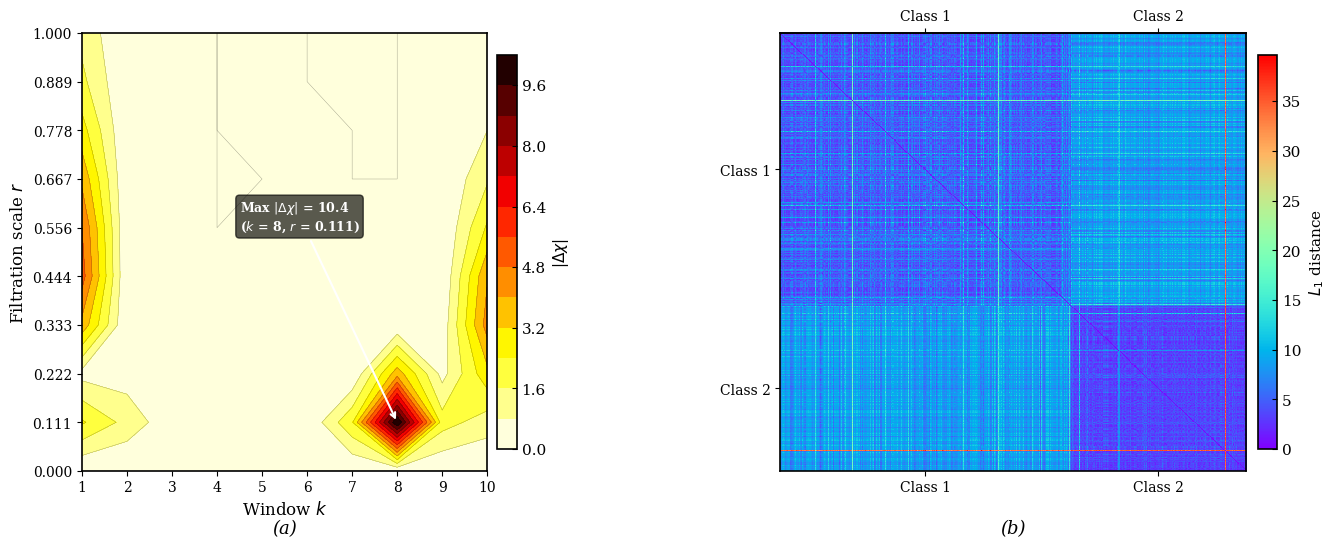

Figure saved.


In [13]:
# ------------------------------------------------------------------
# Publication figure: difference heatmap (a) + L1 heatmap (b)
# ------------------------------------------------------------------
fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [1, 1.15]}
)
fig.subplots_adjust(wspace=0.40, left=0.07, right=0.97, top=0.93, bottom=0.20)

# ── Panel (a): |mean ECS class 0 − mean ECS class 1| ──────────────────────
levels = 15
cf = ax_a.contourf(KK, RR, diff, levels=levels, cmap="hot_r")
ax_a.contour(KK, RR, diff, levels=levels, colors="k", linewidths=0.3, alpha=0.4)

ax_a.set_xlabel(r"Window $k$",           fontsize=12)
ax_a.set_ylabel(r"Filtration scale $r$", fontsize=12)
ax_a.set_xticks(k_vals)
ax_a.set_yticks(sc)
ax_a.set_yticklabels([f"{s:.3f}" for s in sc], fontsize=7)
ax_a.tick_params(labelsize=10, direction="out", top=False, right=False)

cbar_a = fig.colorbar(cf, ax=ax_a, shrink=0.9, pad=0.02)
cbar_a.set_label(r"$|\Delta\chi|$", fontsize=11)

# Annotate maximum divergence
idx_max = np.unravel_index(np.argmax(diff), diff.shape)
k_max   = k_vals[idx_max[0]]
r_max   = r_vals[idx_max[1]]
ax_a.annotate(
    f"Max $|\\Delta\\chi|$ = {diff.max():.1f}\n"
    f"($k$ = {k_max}, $r$ = {r_max:.3f})",
    xy=(k_max, r_max),
    xytext=(WINDOW_ANALYSIS * 0.45, (sc.min() + sc.max()) * 0.55),
    fontsize=9, fontweight="bold", color="white",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.65),
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5)
)

# ── Panel (b): pairwise L1 heatmap ─────────────────────────────────────────
im = ax_b.imshow(DM, cmap="rainbow", aspect="auto", interpolation="nearest")
ax_b.tick_params(labelsize=10, direction="out",
                 top=False, right=False,
                 labeltop=False, labelright=False)

cbar_b = fig.colorbar(im, ax=ax_b, shrink=0.9, pad=0.02)
cbar_b.set_label(r"$L_1$ distance", fontsize=11)

n0   = mask0.sum()
n1   = mask1.sum()
mid0 = n0 / 2 - 0.5
mid1 = n0 + n1 / 2 - 0.5
lbl0 = f"Class {labels[0]}"
lbl1 = f"Class {labels[1]}"

ax_b.set_xticks([mid0, mid1])
ax_b.set_xticklabels([lbl0, lbl1], fontsize=10)

ax_b2 = ax_b.secondary_xaxis("top")
ax_b2.set_xticks([mid0, mid1])
ax_b2.set_xticklabels([lbl0, lbl1], fontsize=10)
ax_b2.tick_params(direction="out", labelsize=10)

ax_b.set_yticks([mid0, mid1])
ax_b.set_yticklabels([lbl0, lbl1], fontsize=10)

# ── Subfigure labels ────────────────────────────────────────────────────────
fig.canvas.draw()
for ax, letter in [(ax_a, "a"), (ax_b, "b")]:
    pos = ax.get_position()
    fig.text(
        pos.x0 + pos.width * 0.5, pos.y0 - 0.08,
        f"({letter})",
        ha="center", va="top", fontsize=13, fontstyle="italic"
    )

plt.savefig(f"{Dataset_name}_ecs_diff_l1.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Part 4 — Helper Classifier Functions

In [14]:
# ------------------------------------------------------------------
# Helper: return AUC >= 0.5 (flip sign if needed)
# ------------------------------------------------------------------
def get_auc_and_flip(y_bin, scores):
    try:
        auc = roc_auc_score(y_bin, scores)
    except Exception:
        return 0.5, False
    if auc < 0.5:
        return roc_auc_score(y_bin, -scores), True
    return auc, False


# ------------------------------------------------------------------
# Single-feature threshold classifier
# Returns dict with all 6 metrics + best_feat_idx + flip flag
# ------------------------------------------------------------------
def evaluate_single_feature(X_tr_f, y_tr_f, X_te_f, y_te_f):
    """
    AUC-ranked single-feature classifier with Youden-J threshold.
    Searches all columns of X_tr_f, picks the best AUC feature,
    then evaluates on X_te_f.
    """
    best_auc, best_idx, best_flip = -np.inf, 0, False
    for i in range(X_tr_f.shape[1]):
        a, fl = get_auc_and_flip(y_tr_f, X_tr_f[:, i])
        if a > best_auc:
            best_auc, best_idx, best_flip = a, i, fl

    tr_scores = X_tr_f[:, best_idx] * (-1 if best_flip else 1)
    te_scores = X_te_f[:, best_idx] * (-1 if best_flip else 1)

    # Youden-J threshold on training data
    fpr_t, tpr_t, thr_t = roc_curve(y_tr_f, tr_scores)
    J   = tpr_t - fpr_t
    thr = thr_t[np.argmax(J)]

    preds = (te_scores >= thr).astype(int)
    auc   = roc_auc_score(y_te_f, te_scores)
    acc   = accuracy_score (y_te_f, preds)
    prec  = precision_score(y_te_f, preds, zero_division=0)
    rec   = recall_score   (y_te_f, preds, zero_division=0)
    f1    = f1_score       (y_te_f, preds, zero_division=0)
    cm    = confusion_matrix(y_te_f, preds, labels=[1, 0])
    tp, fn, fp, tn = cm.ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dict(auc=auc, acc=acc, prec=prec, rec=rec,
                f1=f1, spec=spec,
                best_feat_idx=best_idx, flip=best_flip, thr=thr)


# ------------------------------------------------------------------
# AdaBoost ensemble classifier
# ------------------------------------------------------------------
def evaluate_adaboost(X_tr_f, y_tr_f, X_te_f, y_te_f, n_est=100):
    """
    AdaBoost with decision-stump weak learners.
    Returns dict with all 6 metrics.
    """
    clf = AdaBoostClassifier(
        estimator=None,
        n_estimators=n_est,
        learning_rate=0.5,
        random_state=42
    )
    clf.fit(X_tr_f, y_tr_f)
    probs = clf.predict_proba(X_te_f)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auc  = roc_auc_score  (y_te_f, probs)
    acc  = accuracy_score  (y_te_f, preds)
    prec = precision_score (y_te_f, preds, zero_division=0)
    rec  = recall_score    (y_te_f, preds, zero_division=0)
    f1   = f1_score        (y_te_f, preds, zero_division=0)
    cm   = confusion_matrix(y_te_f, preds, labels=[1, 0])
    tp, fn, fp, tn = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dict(auc=auc, acc=acc, prec=prec, rec=rec,
                f1=f1, spec=spec, clf=clf)

print("Helper classifier functions defined.")

Helper classifier functions defined.


## Part 5 — Single-Feature Classifier

5-fold cross-validation selects the optimal window size K, then the best single ECS feature is identified and evaluated on the held-out test set.

In [15]:
# ------------------------------------------------------------------
# 5-fold CV: search WINDOW in {2, ..., 10}
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_single = {}

print(f"{'WINDOW':>8}   {'Mean 5-fold AUC':>16}")
print("-" * 28)

for WINDOW in range(2, 11):
    fold_aucs = []
    for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
        X_f = build_feature_matrix(
            X_tr[tr_idx], WINDOW, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
        X_v = build_feature_matrix(
            X_tr[val_idx], WINDOW, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
        y_f = y_bin_tr[tr_idx]
        y_v = y_bin_tr[val_idx]

        best_auc_f, best_idx_f, flip_f = -np.inf, 0, False
        for i in range(X_f.shape[1]):
            a, fl = get_auc_and_flip(y_f, X_f[:, i])
            if a > best_auc_f:
                best_auc_f, best_idx_f, flip_f = a, i, fl

        val_scores = X_v[:, best_idx_f] * (-1 if flip_f else 1)
        fold_aucs.append(roc_auc_score(y_v, val_scores))

    cv_results_single[WINDOW] = np.mean(fold_aucs)
    print(f"{WINDOW:>8}   {cv_results_single[WINDOW]:>16.4f}")

BEST_WINDOW_SINGLE = max(cv_results_single, key=cv_results_single.get)
print(f"\nBest window (single-feature): {BEST_WINDOW_SINGLE}"
      f"  |  CV AUC = {cv_results_single[BEST_WINDOW_SINGLE]:.4f}")

  WINDOW    Mean 5-fold AUC
----------------------------
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 376 samples  (window=2) ...
  Processing 93 samples  (window=2) ...
       2             0.8838
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 376 samples  (window=3) ...
  Processing 93 samples  (window=3) ...
       3             0.9674
  Processing 375 samples  (window=4) ...
  Processing 94 samples  (window=4) 

In [16]:
# ------------------------------------------------------------------
# Build final ECS feature matrices with the best window
# ------------------------------------------------------------------
print(f"Extracting ECS features with WINDOW = {BEST_WINDOW_SINGLE} ...")
X_tr_feat = build_feature_matrix(
    X_tr, BEST_WINDOW_SINGLE, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
X_te_feat = build_feature_matrix(
    X_te, BEST_WINDOW_SINGLE, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)

print(f"Train features: {X_tr_feat.shape}")
print(f"Test  features: {X_te_feat.shape}")

# Find best single feature on the full training set
best_stats = {"idx": -1, "auc": 0.0, "flip": False, "thresh": 0.0}
for i in range(X_tr_feat.shape[1]):
    auc_i, flipped = get_auc_and_flip(y_bin_tr, X_tr_feat[:, i])
    if auc_i > best_stats["auc"]:
        best_stats.update({"idx": i, "auc": auc_i, "flip": flipped})

# Youden-J threshold on training data
best_scores_tr = X_tr_feat[:, best_stats["idx"]] * (-1 if best_stats["flip"] else 1)
fpr_tr, tpr_tr, thresholds_tr = roc_curve(y_bin_tr, best_scores_tr)
J = tpr_tr - fpr_tr
best_stats["thresh"] = thresholds_tr[np.argmax(J)]

print(f"\nRESULTS FROM TRAINING:")
print(f"  Best Feature Index : {best_stats['idx']}")
print(f"  Training AUC       : {best_stats['auc']:.4f}")
print(f"  Cutoff Threshold   : {best_stats['thresh']:.6f}")
print(f"  Logic Flipped?     : {best_stats['flip']}")

Extracting ECS features with WINDOW = 10 ...
  Processing 469 samples  (window=10) ...
  Processing 4217 samples  (window=10) ...
Train features: (469, 100)
Test  features: (4217, 100)

RESULTS FROM TRAINING:
  Best Feature Index : 71
  Training AUC       : 0.9962
  Cutoff Threshold   : -3.000000
  Logic Flipped?     : True


In [17]:
# ------------------------------------------------------------------
# Evaluate on test set (single best feature + Youden threshold)
# ------------------------------------------------------------------
test_scores = X_te_feat[:, best_stats["idx"]] * (-1 if best_stats["flip"] else 1)
predictions = (test_scores >= best_stats["thresh"]).astype(int)

acc  = accuracy_score (y_bin_te, predictions)
prec = precision_score(y_bin_te, predictions, zero_division=0)
rec  = recall_score   (y_bin_te, predictions, zero_division=0)
f1   = f1_score       (y_bin_te, predictions, zero_division=0)
auc  = roc_auc_score  (y_bin_te, test_scores)
cm   = confusion_matrix(y_bin_te, predictions)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
npv         = tn / (tn + fn) if (tn + fn) > 0 else float("nan")

print("=== FINAL SINGLE-FEATURE TEST RESULTS ===")
print(f"  Test ROC-AUC      : {auc:.6f}")
print(f"  Test Accuracy     : {acc:.6f}")
print(f"  Test Precision    : {prec:.6f}")
print(f"  Test Recall (Sens): {rec:.6f}")
print(f"  Test Specificity  : {specificity:.6f}")
print(f"  Test F1 Score     : {f1:.6f}")
print(f"  Test NPV          : {npv:.6f}")
print("\nConfusion Matrix (rows=Actual, cols=Predicted):")
print(cm)
print("\nFull Classification Report:")
print(classification_report(y_bin_te, predictions,
                             target_names=[str(labels[0]), str(labels[1])]))

=== FINAL SINGLE-FEATURE TEST RESULTS ===
  Test ROC-AUC      : 0.993691
  Test Accuracy     : 0.980318
  Test Precision    : 0.985190
  Test Recall (Sens): 0.962264
  Test Specificity  : 0.991245
  Test F1 Score     : 0.973592
  Test NPV          : 0.977477

Confusion Matrix (rows=Actual, cols=Predicted):
[[2604   23]
 [  60 1530]]

Full Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.99      0.98      2627
           2       0.99      0.96      0.97      1590

    accuracy                           0.98      4217
   macro avg       0.98      0.98      0.98      4217
weighted avg       0.98      0.98      0.98      4217



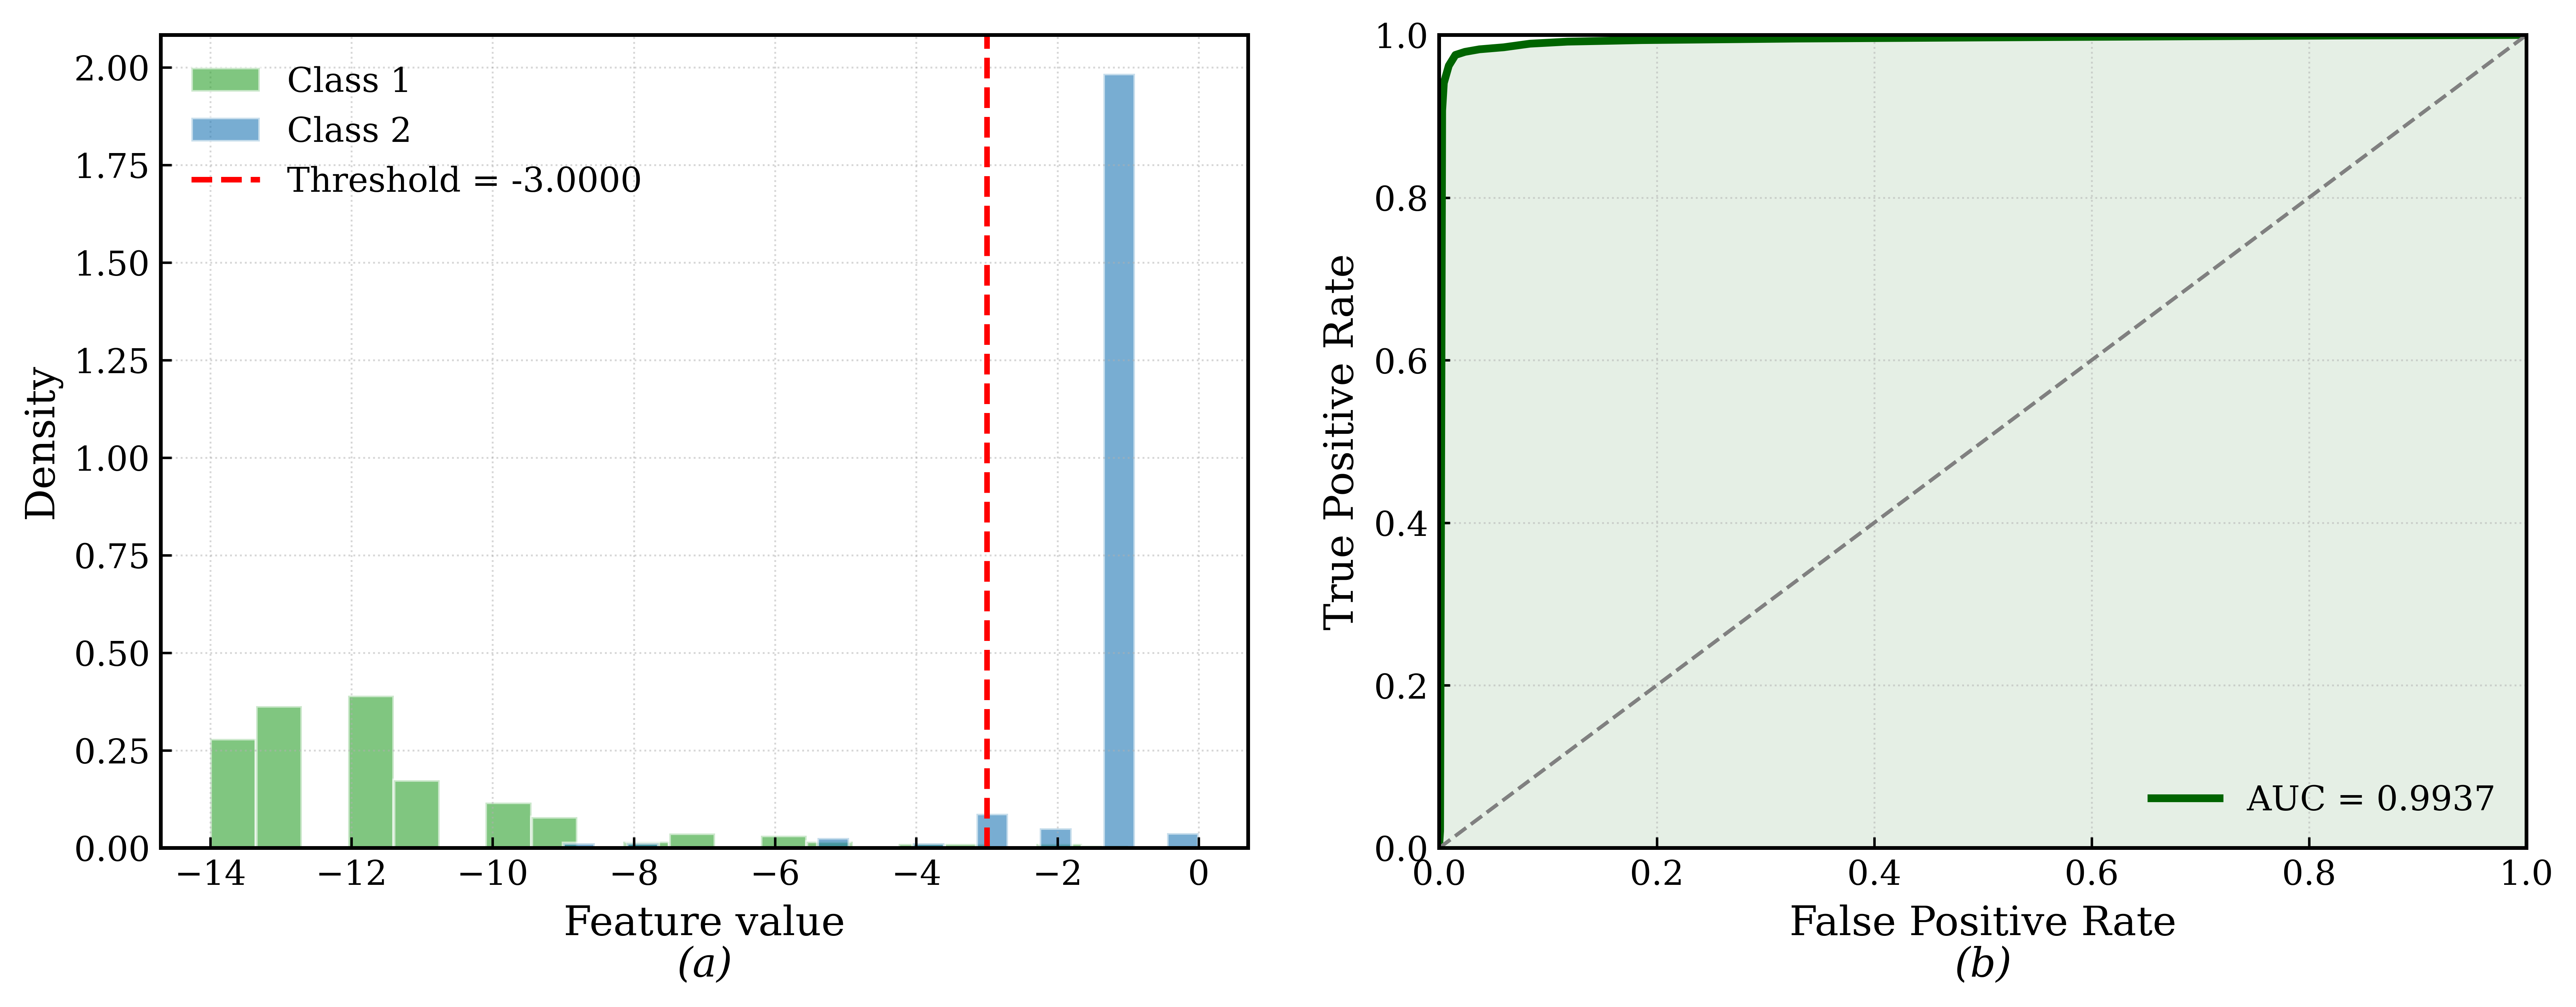

Figure saved.


In [18]:
# ------------------------------------------------------------------
# Publication figure: density histogram (a) + ROC on test data (b)
# ------------------------------------------------------------------
train_scores = X_tr_feat[:, best_stats["idx"]] * (-1 if best_stats["flip"] else 1)

fpr, tpr, _ = roc_curve(y_bin_te, test_scores)
auc_val     = roc_auc_score(y_bin_te, test_scores)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), dpi=600)

# (a) Best-feature density — training set
ax_hist = axes2[0]
ax_hist.hist(train_scores[y_bin_tr == 0], bins=20, alpha=0.6, density=True,
             color="tab:green", edgecolor="white", lw=0.4,
             label=f"Class {labels[0]}")
ax_hist.hist(train_scores[y_bin_tr == 1], bins=20, alpha=0.6, density=True,
             color="tab:blue", edgecolor="white", lw=0.4,
             label=f"Class {labels[1]}")
ax_hist.axvline(best_stats["thresh"], color="red", ls="--", lw=1.8,
                label=f"Threshold = {best_stats['thresh']:.4f}")
ax_hist.set_xlabel("Feature value"); ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.tick_params(direction="in", which="both", top=False, right=False)
ax_hist.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_hist.text(0.5, -0.12, "(a)", transform=ax_hist.transAxes,
             ha="center", va="top", fontsize=13, fontstyle="italic")

# (b) ROC curve on test data
ax_roc = axes2[1]
ax_roc.plot(fpr, tpr, color="darkgreen", lw=2.5,
            label=rf"AUC = {auc_val:.4f}")
ax_roc.fill_between(fpr, tpr, alpha=0.10, color="darkgreen")
ax_roc.plot([0, 1], [0, 1], color="gray", ls="--", lw=1.2)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)
ax_roc.set_xticks(np.linspace(0, 1, 6)); ax_roc.set_yticks(np.linspace(0, 1, 6))
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")
ax_roc.tick_params(direction="in", which="both", top=False, right=False)
ax_roc.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_roc.text(0.5, -0.12, "(b)", transform=ax_roc.transAxes,
            ha="center", va="top", fontsize=13, fontstyle="italic")

fig2.tight_layout(pad=2.0)
fig2.savefig(f"{Dataset_name}_density_roc.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Part 6 — AdaBoost Classifier

In [19]:
# ------------------------------------------------------------------
# 5-fold CV window search — AdaBoost with n_estimators = WINDOW^2
# ------------------------------------------------------------------
cv_results_ada = {}

print(f"{'WINDOW':>8}   {'n_stumps':>10}   {'Mean 5-fold AUC':>16}")
print("-" * 40)

for WINDOW in range(2, 11):
    n_est     = WINDOW ** 2
    fold_aucs = []

    for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
        X_f = build_feature_matrix(
            X_tr[tr_idx], WINDOW, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
        X_v = build_feature_matrix(
            X_tr[val_idx], WINDOW, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
        y_f = y_bin_tr[tr_idx]
        y_v = y_bin_tr[val_idx]

        clf_cv = AdaBoostClassifier(
            estimator=None, n_estimators=n_est,
            learning_rate=0.5, random_state=42
        )
        clf_cv.fit(X_f, y_f)
        val_probs = clf_cv.predict_proba(X_v)[:, 1]
        fold_aucs.append(roc_auc_score(y_v, val_probs))

    cv_results_ada[WINDOW] = np.mean(fold_aucs)
    print(f"{WINDOW:>8}   {n_est:>10}   {cv_results_ada[WINDOW]:>16.4f}")

BEST_WINDOW_ADA = max(cv_results_ada, key=cv_results_ada.get)
N_STUMPS        = BEST_WINDOW_ADA ** 2

print(f"\nBest window (AdaBoost) : {BEST_WINDOW_ADA}")
print(f"n_estimators           : {N_STUMPS}")
print(f"Best CV AUC            : {cv_results_ada[BEST_WINDOW_ADA]:.4f}")

  WINDOW     n_stumps    Mean 5-fold AUC
----------------------------------------
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 376 samples  (window=2) ...
  Processing 93 samples  (window=2) ...
       2            4             0.8711
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 376 samples  (window=3) ...
  Processing 93 samples  (window=3) ...
       3            9             0.9914
  Processing 375 samples  

In [20]:
# ------------------------------------------------------------------
# Reuse ECS features if best window matches; else re-extract
# ------------------------------------------------------------------
if BEST_WINDOW_ADA == BEST_WINDOW_SINGLE:
    print("Reusing previously extracted ECS features (same best window).")
    X_tr_feat_ada = X_tr_feat
    X_te_feat_ada = X_te_feat
else:
    print(f"Re-extracting ECS features with WINDOW = {BEST_WINDOW_ADA} ...")
    X_tr_feat_ada = build_feature_matrix(
        X_tr, BEST_WINDOW_ADA, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
    X_te_feat_ada = build_feature_matrix(
        X_te, BEST_WINDOW_ADA, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)

# Train final AdaBoost
clf_ada = AdaBoostClassifier(
    estimator=None, n_estimators=N_STUMPS,
    learning_rate=0.5, random_state=42
)
clf_ada.fit(X_tr_feat_ada, y_bin_tr)

probs_ada = clf_ada.predict_proba(X_te_feat_ada)[:, 1]
preds_ada = (probs_ada >= 0.5).astype(int)

auc_ada  = roc_auc_score  (y_bin_te, probs_ada)
acc_ada  = accuracy_score  (y_bin_te, preds_ada)
prec_ada = precision_score (y_bin_te, preds_ada, zero_division=0)
rec_ada  = recall_score    (y_bin_te, preds_ada, zero_division=0)
f1_ada   = f1_score        (y_bin_te, preds_ada, zero_division=0)
cm_ada   = confusion_matrix(y_bin_te, preds_ada)
tn_a, fp_a, fn_a, tp_a = cm_ada.ravel()
spec_ada = tn_a / (tn_a + fp_a)
npv_ada  = tn_a / (tn_a + fn_a) if (tn_a + fn_a) > 0 else float("nan")

print("=== ADABOOST TEST RESULTS ===")
print(f"  Test ROC-AUC      : {auc_ada:.6f}")
print(f"  Test Accuracy     : {acc_ada:.6f}")
print(f"  Test Precision    : {prec_ada:.6f}")
print(f"  Test Recall (Sens): {rec_ada:.6f}")
print(f"  Test Specificity  : {spec_ada:.6f}")
print(f"  Test F1 Score     : {f1_ada:.6f}")
print(f"  Test NPV          : {npv_ada:.6f}")
print("\nConfusion Matrix (rows=Actual, cols=Predicted):")
print(cm_ada)
print("\nFull Classification Report:")
print(classification_report(y_bin_te, preds_ada,
                             target_names=[str(labels[0]), str(labels[1])]))

Re-extracting ECS features with WINDOW = 6 ...
  Processing 469 samples  (window=6) ...
  Processing 4217 samples  (window=6) ...
=== ADABOOST TEST RESULTS ===
  Test ROC-AUC      : 0.998797
  Test Accuracy     : 0.985535
  Test Precision    : 0.984781
  Test Recall (Sens): 0.976730
  Test Specificity  : 0.990864
  Test F1 Score     : 0.980739
  Test NPV          : 0.985985

Confusion Matrix (rows=Actual, cols=Predicted):
[[2603   24]
 [  37 1553]]

Full Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      2627
           2       0.98      0.98      0.98      1590

    accuracy                           0.99      4217
   macro avg       0.99      0.98      0.98      4217
weighted avg       0.99      0.99      0.99      4217



### 6.1 — Alpha-contribution heatmap (x-axis = Window k, y-axis = filtration scale r)

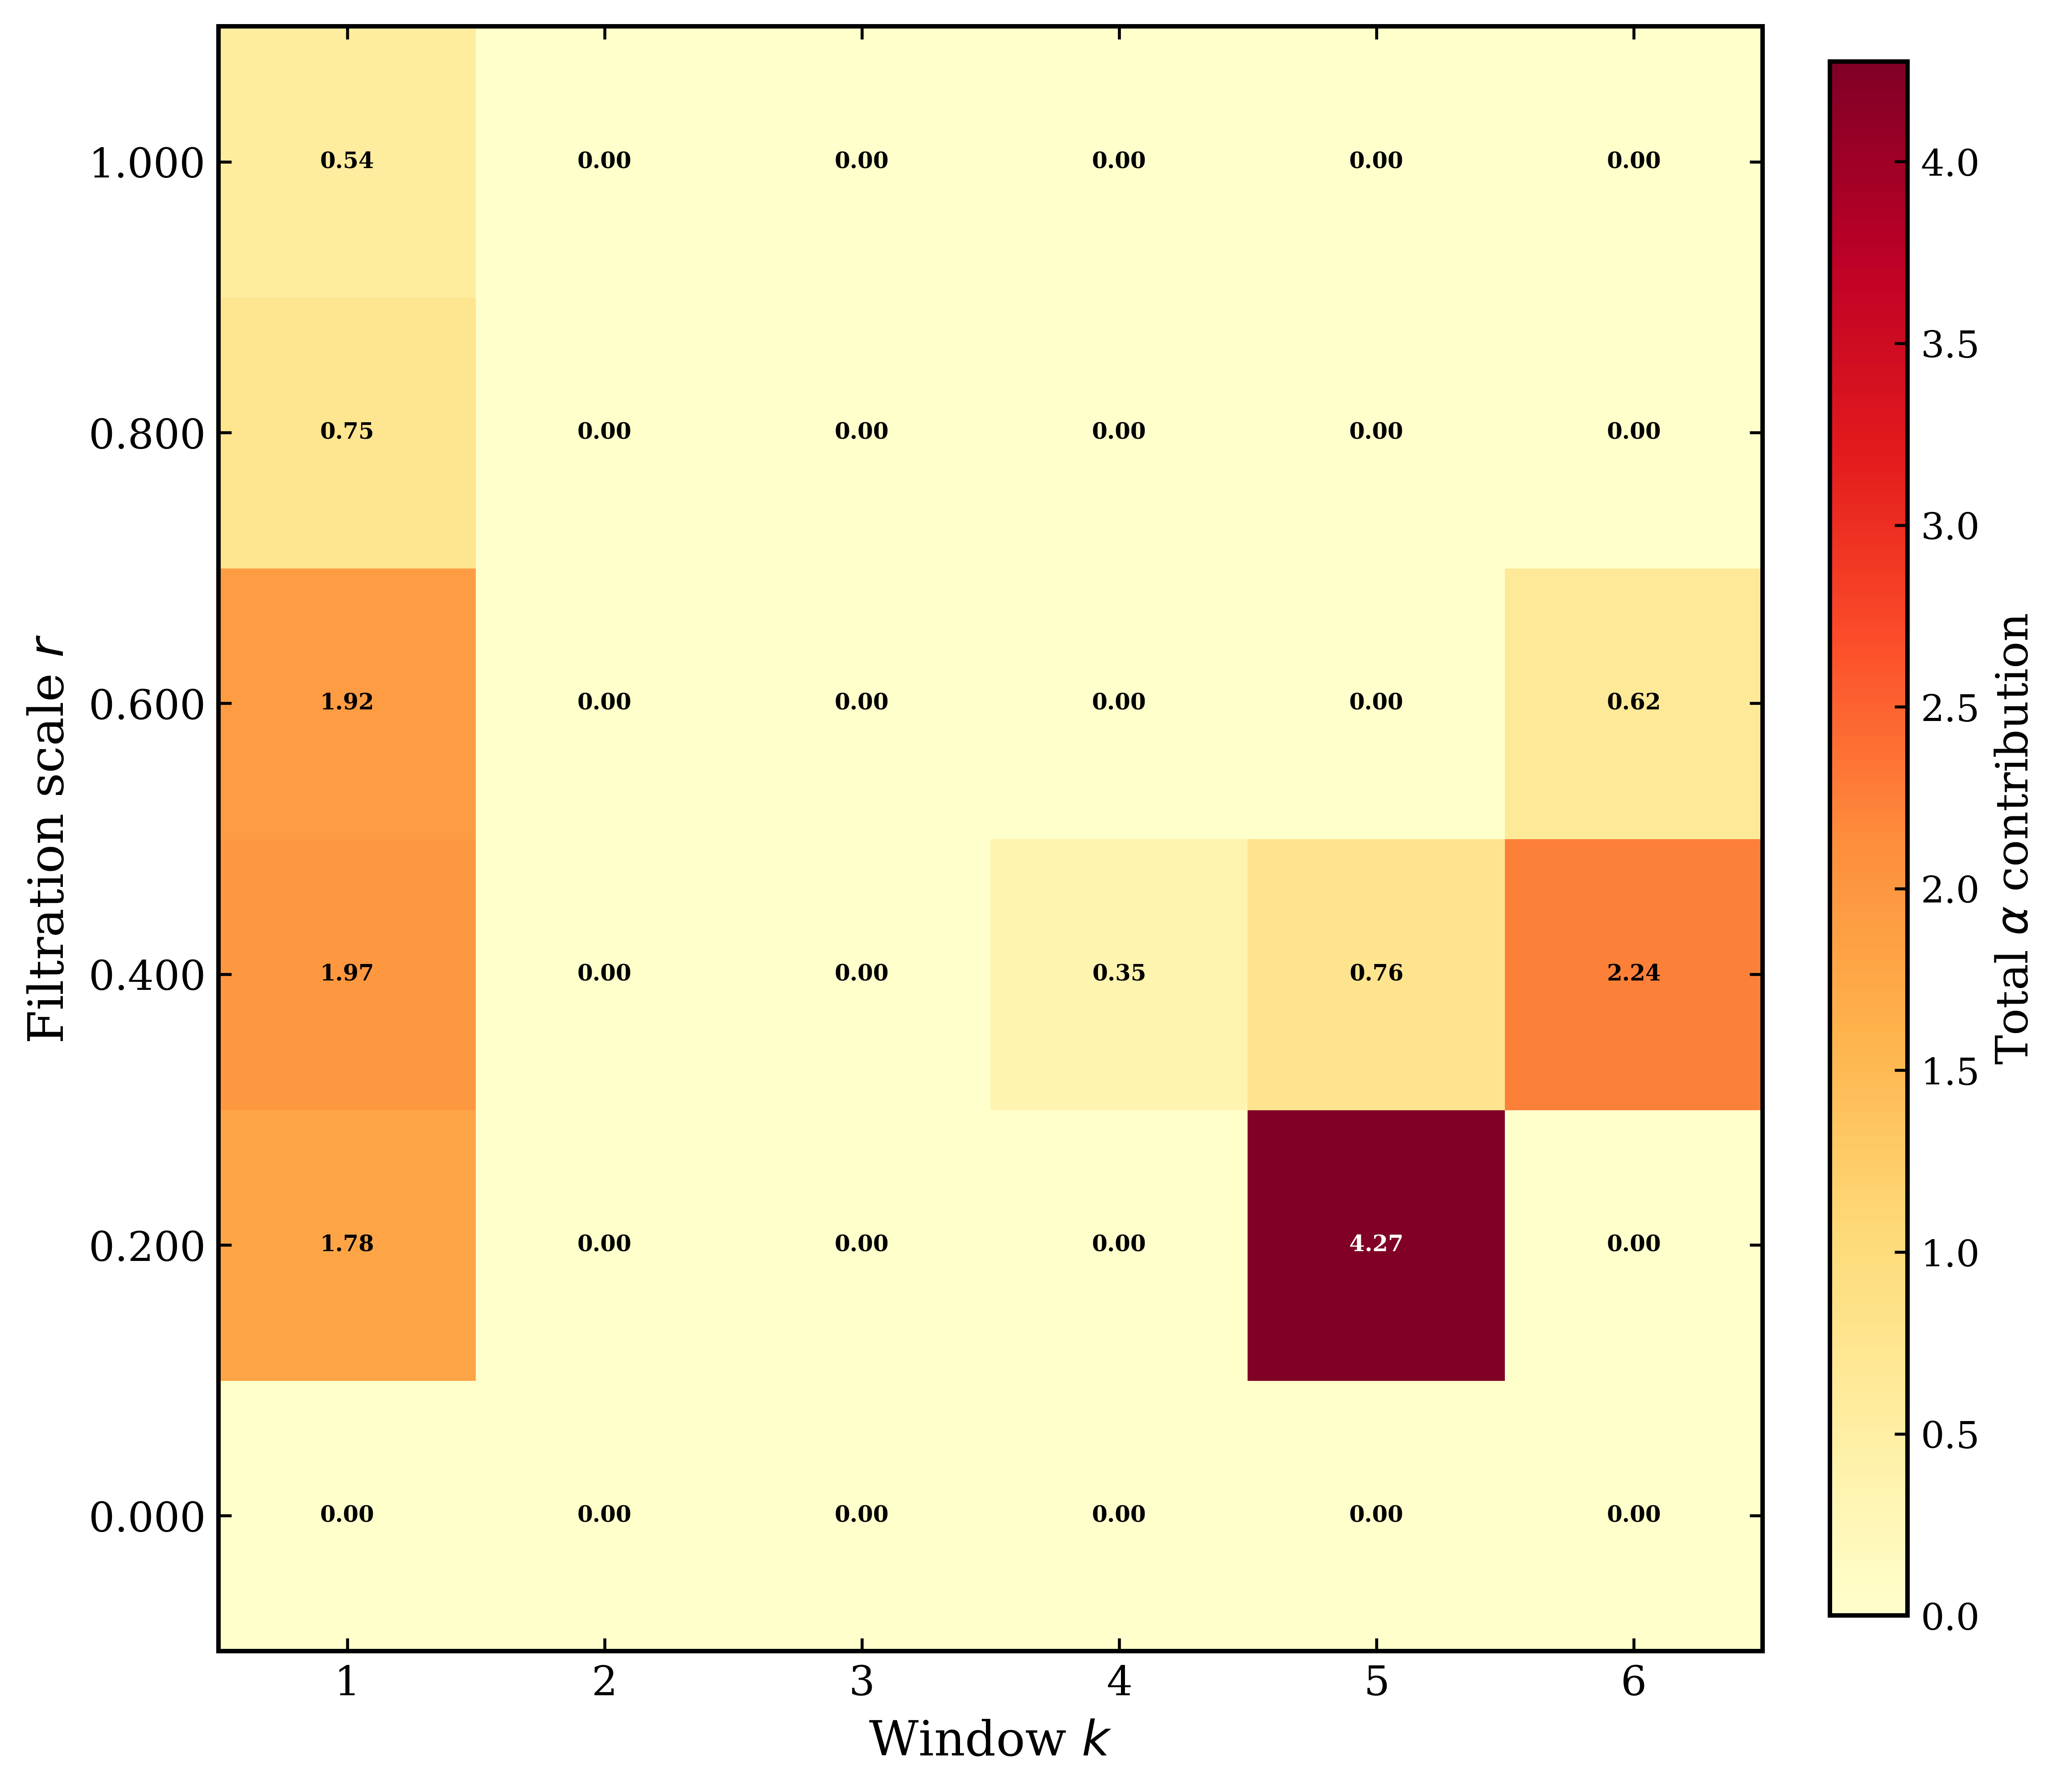

Figure saved.


In [21]:
# ------------------------------------------------------------------
# Compute total alpha contribution per ECS feature
# Reshape and transpose so x-axis = window k, y-axis = scale r
# ------------------------------------------------------------------
feature_alpha_sum = np.zeros(X_tr_feat_ada.shape[1])
for estimator, weight in zip(clf_ada.estimators_, clf_ada.estimator_weights_):
    feat_index = estimator.tree_.feature[0]
    feature_alpha_sum[feat_index] += abs(weight)

# Transpose: rows=scale, cols=window
importance_grid = feature_alpha_sum.reshape(BEST_WINDOW_ADA, BEST_WINDOW_ADA).T

SCALES_ADA    = np.linspace(1e-20, SCALE_MAX, BEST_WINDOW_ADA)
window_labels = [f"{k}" for k in range(1, BEST_WINDOW_ADA + 1)]

# ------------------------------------------------------------------
# Publication figure: alpha-contribution heatmap
# ------------------------------------------------------------------
fig_hm, ax_hm = plt.subplots(figsize=(8, 7), dpi=600)

im_hm = ax_hm.imshow(
    importance_grid, cmap="YlOrRd",
    origin="lower", aspect="auto", interpolation="nearest",
)

cbar_hm = fig_hm.colorbar(im_hm, ax=ax_hm, fraction=0.046, pad=0.04)
cbar_hm.set_label(r"Total $\alpha$ contribution", fontsize=12)
cbar_hm.ax.tick_params(labelsize=10, direction="in")

vmax = importance_grid.max()
fs   = max(6, 10 - BEST_WINDOW_ADA)

for row in range(BEST_WINDOW_ADA):
    for col in range(BEST_WINDOW_ADA):
        val = importance_grid[row, col]
        ax_hm.text(col, row, f"{val:.2f}",
                   ha="center", va="center",
                   fontsize=fs, fontweight="bold",
                   color="white" if val > 0.55 * vmax else "black")

# x-axis = window k,  y-axis = filtration scale r
ax_hm.set_xticks(range(BEST_WINDOW_ADA))
ax_hm.set_xticklabels(window_labels)
ax_hm.set_yticks(range(BEST_WINDOW_ADA))
ax_hm.set_yticklabels([f"{s:.3f}" for s in SCALES_ADA])
ax_hm.set_xlabel(r"Window $k$",            fontsize=13)
ax_hm.set_ylabel(r"Filtration scale $r$",  fontsize=13)
ax_hm.tick_params(direction="in")

fig_hm.tight_layout(pad=1.5)
fig_hm.savefig(f"{Dataset_name}_alpha_heatmap.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved.")

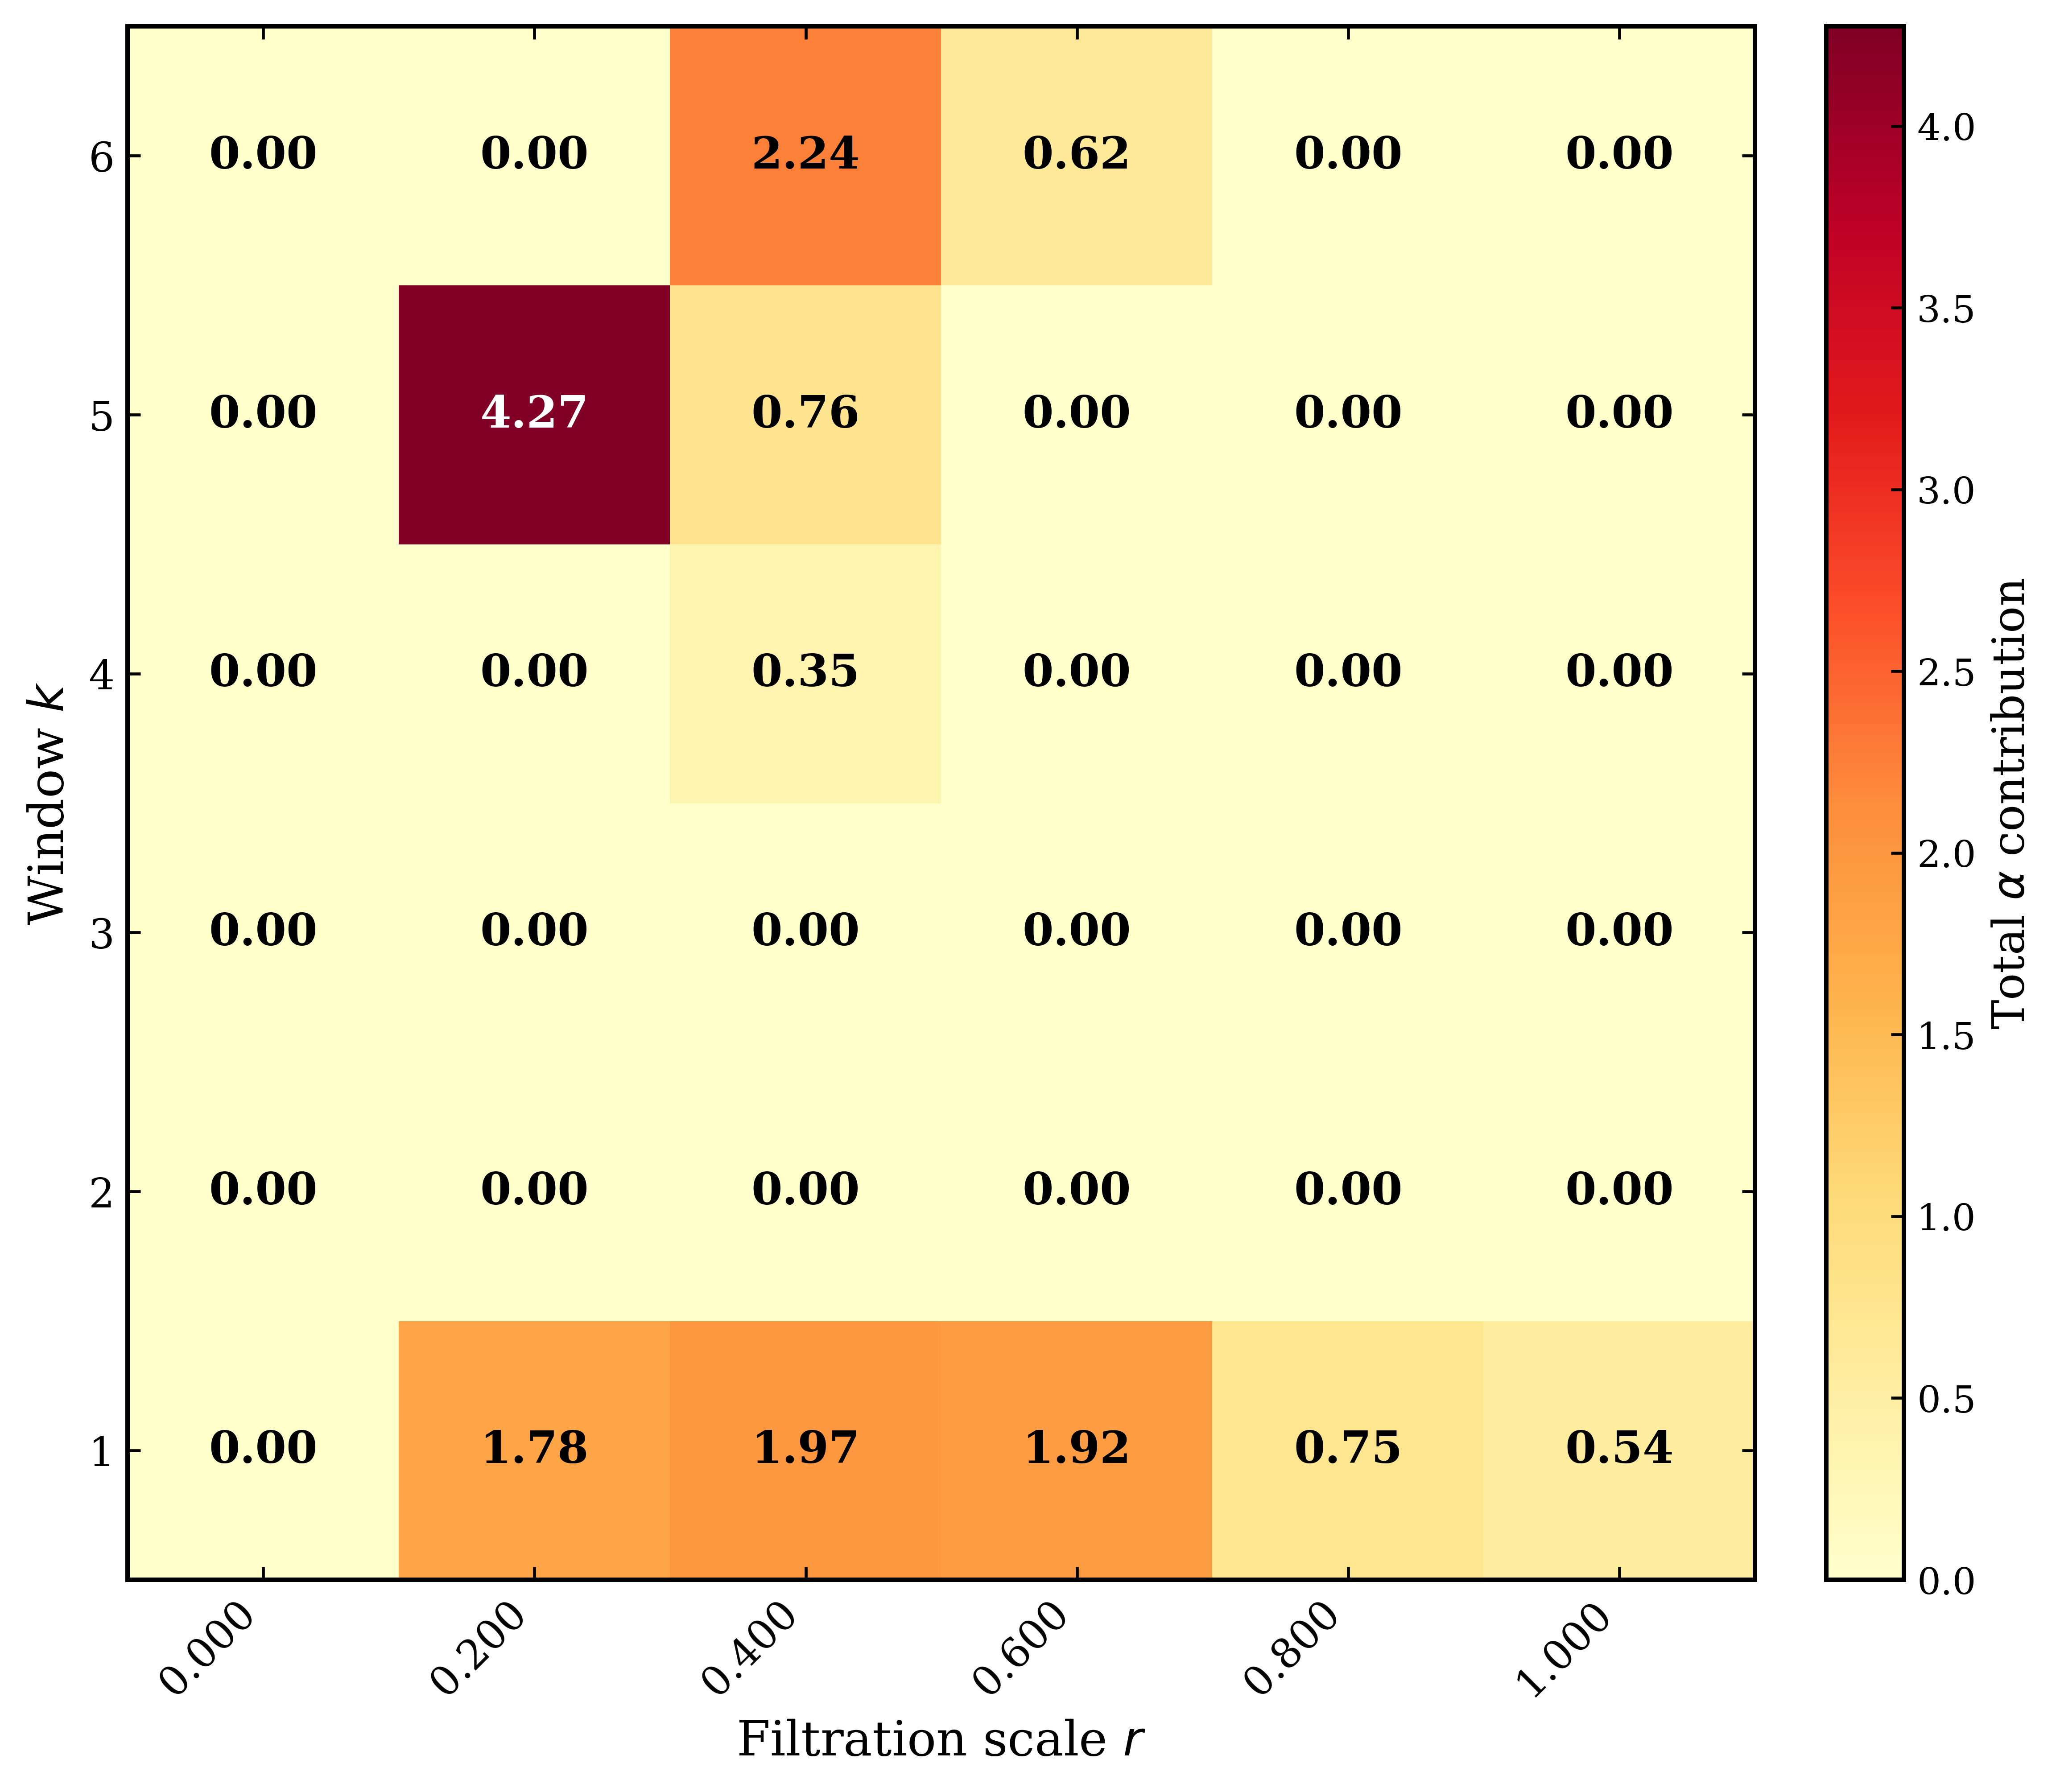

Figure saved.

Top-10 ECS features by alpha contribution  (window = 6):
  Rank   Feat  Window k   ScaleCol   Alpha sum
  --------------------------------------------
     1     25         5          1    4.274622
     2     32         6          2    2.239988
     3      2         1          2    1.971270
     4      3         1          3    1.916535
     5      1         1          1    1.778860
     6     26         5          2    0.763830
     7      4         1          4    0.748575
     8     33         6          3    0.620076
     9      5         1          5    0.536325
    10     20         4          2    0.345620


In [22]:
# ------------------------------------------------------------------
# Compute total alpha contribution per ECS feature
# ------------------------------------------------------------------
feature_alpha_sum = np.zeros(X_tr_feat_ada.shape[1])

for estimator, weight in zip(clf_ada.estimators_, clf_ada.estimator_weights_):
    feat_index = estimator.tree_.feature[0]
    feature_alpha_sum[feat_index] += abs(weight)

# Reshape to WINDOW × WINDOW grid (no transpose)
# rows = window k,  cols = filtration scale r
importance_grid = feature_alpha_sum.reshape(BEST_WINDOW_ADA, BEST_WINDOW_ADA)

SCALES_ADA    = np.linspace(1e-20, SCALE_MAX, BEST_WINDOW_ADA)
window_labels = [f"{k}" for k in range(1, BEST_WINDOW_ADA + 1)]

# ------------------------------------------------------------------
# Publication figure: alpha-contribution heatmap
# ------------------------------------------------------------------
fig_hm, ax_hm = plt.subplots(figsize=(8, 7), dpi=600)

im_hm = ax_hm.imshow(
    importance_grid,
    cmap          = "YlOrRd",
    origin        = "lower",
    aspect        = "auto",
    interpolation = "nearest",
)

cbar_hm = fig_hm.colorbar(im_hm, ax=ax_hm, fraction=0.046, pad=0.04)
cbar_hm.set_label(r"Total $\alpha$ contribution", fontsize=12)
cbar_hm.ax.tick_params(labelsize=10, direction="in")

# ------------------------------------------------------------------
# Annotate every cell
# ------------------------------------------------------------------
vmax = importance_grid.max()

for row in range(BEST_WINDOW_ADA):
    for col in range(BEST_WINDOW_ADA):
        val = importance_grid[row, col]
        ax_hm.text(
            col, row,
            f"{val:.2f}",
            ha         = "center",
            va         = "center",
            fontsize   = 12,
            fontweight = "bold",
            color      = "white" if val > 0.55 * vmax else "black"
        )

# ------------------------------------------------------------------
# x-axis = filtration scale r (rotated),  y-axis = window k
# ------------------------------------------------------------------
ax_hm.set_xticks(range(BEST_WINDOW_ADA))
ax_hm.set_xticklabels([f"{s:.3f}" for s in SCALES_ADA], rotation=45, ha="right")

ax_hm.set_yticks(range(BEST_WINDOW_ADA))
ax_hm.set_yticklabels(window_labels)

ax_hm.set_xlabel(r"Filtration scale $r$", fontsize=13)
ax_hm.set_ylabel(r"Window $k$",           fontsize=13)
ax_hm.tick_params(direction="in")

fig_hm.tight_layout(pad=1.5)
fig_hm.savefig(f"{Dataset_name}_alpha_heatmap.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved.")

# ------------------------------------------------------------------
# Print top-10 most important features
# ------------------------------------------------------------------
sorted_idx = np.argsort(feature_alpha_sum)[::-1]
print(f"\nTop-10 ECS features by alpha contribution  (window = {BEST_WINDOW_ADA}):")
print(f"  {'Rank':>4}  {'Feat':>5}  {'Window k':>8}  {'ScaleCol':>9}  {'Alpha sum':>10}")
print("  " + "-" * 44)
for rank, idx in enumerate(sorted_idx[:10], 1):
    row_i = idx // BEST_WINDOW_ADA
    col_i = idx %  BEST_WINDOW_ADA
    print(f"  {rank:>4}  {idx:>5}  {row_i+1:>8}  {col_i:>9}  {feature_alpha_sum[idx]:>10.6f}")

## Part 7 — Ablation Studies

### Ablation map
| Label | Description |
|-------|-------------|
| **A1** | ECC (K=1, no temporal partitioning) vs ECS SF vs ECS AdaBoost |
| **A2** | K-sensitivity sweep: CV AUC vs K |
| **B1** | Mean amplitude in best window k* |
| **B2** | Std of amplitude in best window k* |
| **B3** | Range (max−min) in best window k* |
| **B4** | Multi-stat (mean+std+range) + AdaBoost |
| **B5** | Shapelet distance from best window k* |
| **B6** | ECS χ at (r*, k*) — exact comparison point |
| **B7** | ECS AdaBoost (full grid) |

### 7.1 — Ablation A1: ECC (K=1) vs ECS SF vs ECS AdaBoost

In [23]:
# ============================================================
# Ablation A1: ECC (K=1) — no temporal partitioning
# ============================================================
print("=" * 60)
print("ABLATION A1: ECC (K=1) — no temporal partitioning")
print("=" * 60)

N_SCALES = 10   # number of scale grid points for the EC curve

print("\nBuilding ECC (K=1, N_SCALES-scale sweep)...")
print("  Training set...", end=" ")
X_tr_ecc_full = ecc_feature_matrix(X_tr, DIM, DELAY, SCALE_MAX, N_SCALES)
print("done.")
print("  Test set...", end=" ")
X_te_ecc_full = ecc_feature_matrix(X_te, DIM, DELAY, SCALE_MAX, N_SCALES)
print("done.")
print(f"ECC feature shape: {X_tr_ecc_full.shape}")

res_ecc = evaluate_single_feature(
    X_tr_ecc_full, y_bin_tr, X_te_ecc_full, y_bin_te)

scales_N = np.linspace(1e-20, SCALE_MAX, N_SCALES)
best_r   = scales_N[res_ecc['best_feat_idx']]

print(f"\nECC (K=1) — single best filtration scale:")
print(f"  AUC          = {res_ecc['auc']:.4f}")
print(f"  Accuracy     = {res_ecc['acc']:.4f}")
print(f"  F1           = {res_ecc['f1']:.4f}")
print(f"  Best r       = {best_r:.4f}  (index {res_ecc['best_feat_idx']})")

ABLATION A1: ECC (K=1) — no temporal partitioning

Building ECC (K=1, N_SCALES-scale sweep)...
  Training set... done.
  Test set... done.
ECC feature shape: (469, 10)

ECC (K=1) — single best filtration scale:
  AUC          = 0.9593
  Accuracy     = 0.8980
  F1           = 0.8723
  Best r       = 0.6667  (index 6)


### 7.2 — Ablation A2: K-sensitivity sweep

In [24]:
# ============================================================
# Ablation A2: AUC vs K sweep (K = 1 to 10)
# Uses same 5-fold CV protocol as main manuscript.
# ============================================================
print("=" * 60)
print("ABLATION A2: K-sensitivity sweep (K = 1 to 10)")
print("=" * 60)

k_sweep_results = {}

print(f"\n{'K':>4}  {'CV AUC (5-fold)':>18}")
print("-" * 26)

for K in range(1, 11):
    if K == 1:
        fold_aucs = []
        for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
            Xf = ecc_feature_matrix(X_tr[tr_idx], DIM, DELAY, SCALE_MAX, N_SCALES)
            Xv = ecc_feature_matrix(X_tr[val_idx], DIM, DELAY, SCALE_MAX, N_SCALES)
            yf, yv = y_bin_tr[tr_idx], y_bin_tr[val_idx]
            best_a, best_fl, best_i = -np.inf, False, 0
            for i in range(Xf.shape[1]):
                a, fl = get_auc_and_flip(yf, Xf[:, i])
                if a > best_a:
                    best_a, best_i, best_fl = a, i, fl
            sc = Xv[:, best_i] * (-1 if best_fl else 1)
            fold_aucs.append(roc_auc_score(yv, sc))
    else:
        fold_aucs = []
        for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
            Xf = build_feature_matrix(X_tr[tr_idx], K, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
            Xv = build_feature_matrix(X_tr[val_idx], K, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
            yf, yv = y_bin_tr[tr_idx], y_bin_tr[val_idx]
            best_a, best_fl, best_i = -np.inf, False, 0
            for i in range(Xf.shape[1]):
                a, fl = get_auc_and_flip(yf, Xf[:, i])
                if a > best_a:
                    best_a, best_i, best_fl = a, i, fl
            sc = Xv[:, best_i] * (-1 if best_fl else 1)
            fold_aucs.append(roc_auc_score(yv, sc))

    k_sweep_results[K] = np.mean(fold_aucs)
    print(f"{K:>4}  {k_sweep_results[K]:>18.4f}")

BEST_K = max(k_sweep_results, key=k_sweep_results.get)
print(f"\nBest K = {BEST_K}  (CV AUC = {k_sweep_results[BEST_K]:.4f})")

ABLATION A2: K-sensitivity sweep (K = 1 to 10)

   K     CV AUC (5-fold)
--------------------------
   1              0.9528
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 375 samples  (window=2) ...
  Processing 94 samples  (window=2) ...
  Processing 376 samples  (window=2) ...
  Processing 93 samples  (window=2) ...
   2              0.8838
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 375 samples  (window=3) ...
  Processing 94 samples  (window=3) ...
  Processing 376 samples  (window=3) ...
  Processing 93 samples  (window=3) ...
   3              0.9674
  Processing 37

### 7.3 — Build ECS at best K and run A3 (Single-feature vs AdaBoost)

In [25]:
# ============================================================
# Ablation A3: Single-feature vs AdaBoost (K=BEST_K)
# ============================================================
print("=" * 60)
print(f"ABLATION A3: Single-feature vs AdaBoost (K={BEST_K})")
print("=" * 60)

print(f"\nBuilding ECS features for K={BEST_K}...")
X_tr_ecs = build_feature_matrix(X_tr, BEST_K, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
X_te_ecs = build_feature_matrix(X_te, BEST_K, DIM, DELAY, SCALE_MAX, REQUIRED_LENGTH)
print(f"Feature shape: {X_tr_ecs.shape}")

# Single-feature
res_sf = evaluate_single_feature(X_tr_ecs, y_bin_tr, X_te_ecs, y_bin_te)
print(f"\nECS Single-feature (K={BEST_K}):")
print(f"  AUC={res_sf['auc']:.4f}  Acc={res_sf['acc']:.4f}  F1={res_sf['f1']:.4f}")

# Decode best feature into (k, r) coordinates
feat_idx   = res_sf['best_feat_idx']
scales_K   = np.linspace(1e-20, SCALE_MAX, BEST_K)
BEST_K_IDX = feat_idx // BEST_K   # 0-indexed window
BEST_R_IDX = feat_idx  % BEST_K   # scale index
BEST_R_VAL = scales_K[BEST_R_IDX]
best_k_val = BEST_K_IDX + 1       # 1-indexed

print(f"  Best ECS coordinate: window k={best_k_val}, filtration scale r≈{BEST_R_VAL:.3f}")

# AdaBoost
n_stumps = BEST_K ** 2
res_ada_abl = evaluate_adaboost(X_tr_ecs, y_bin_tr, X_te_ecs, y_bin_te, n_stumps)
print(f"\nECS AdaBoost (K={BEST_K}, T={n_stumps}):")
print(f"  AUC={res_ada_abl['auc']:.4f}  Acc={res_ada_abl['acc']:.4f}  F1={res_ada_abl['f1']:.4f}")

ABLATION A3: Single-feature vs AdaBoost (K=10)

Building ECS features for K=10...
  Processing 469 samples  (window=10) ...
  Processing 4217 samples  (window=10) ...
Feature shape: (469, 100)

ECS Single-feature (K=10):
  AUC=0.9937  Acc=0.9803  F1=0.9736
  Best ECS coordinate: window k=8, filtration scale r≈0.111

ECS AdaBoost (K=10, T=100):
  AUC=0.9976  Acc=0.9839  F1=0.9783


### 7.4 — Ablation B: Topology vs raw time-domain features from best window

All B configurations receive the ground-truth window k* discovered by ECS. Any residual advantage of B6 (ECS chi) is a conservative lower bound on topological added value.

In [26]:
# ============================================================
# Determine raw signal time-step range of best window k*
# For tau=1: point-cloud index i == raw signal index i
# ============================================================
PC_LEN  = REQUIRED_LENGTH - (DIM - 1) * DELAY
step_pc = PC_LEN // BEST_K + (1 if PC_LEN % BEST_K != 0 else 0)

pc_start = BEST_K_IDX * step_pc
pc_end   = PC_LEN if BEST_K_IDX == BEST_K - 1 else pc_start + step_pc

# Takens point cloud index i corresponds to raw signal index i (for delay=1)
raw_start = int(pc_start)
raw_end   = int(min(pc_end + (DIM - 1) * DELAY, REQUIRED_LENGTH))

print(f"Best ECS window : k={best_k_val} (0-indexed: {BEST_K_IDX})")
print(f"Corresponding raw signal time steps: {raw_start} to {raw_end-1}")
print(f"Window width    : {raw_end - raw_start} samples")
print(f"Best filtration scale: r ≈ {BEST_R_VAL:.4f}")

Best ECS window : k=8 (0-indexed: 7)
Corresponding raw signal time steps: 98 to 113
Window width    : 16 samples
Best filtration scale: r ≈ 0.1111


In [27]:
# ============================================================
# Raw time-domain feature matrices from best window
# ============================================================
def raw_window_features(X, start, end):
    """
    Extract mean, std, and range from raw signal in [start:end].
    Returns (N, 3) array: columns = [mean, std, range].
    """
    rows = []
    for x in X:
        seg = np.asarray(x, dtype=float).flatten()[start:end]
        rows.append([seg.mean(), seg.std(), seg.max() - seg.min()])
    return np.array(rows)

print("Extracting raw time-domain features from best ECS window...")
F_tr_raw = raw_window_features(X_tr, raw_start, raw_end)
F_te_raw = raw_window_features(X_te, raw_start, raw_end)
print(f"Raw feature matrix shape: {F_tr_raw.shape}  (mean, std, range)")

# B1 — Mean amplitude
res_B1 = evaluate_single_feature(
    F_tr_raw[:, [0]], y_bin_tr, F_te_raw[:, [0]], y_bin_te)
# B2 — Std of amplitude
res_B2 = evaluate_single_feature(
    F_tr_raw[:, [1]], y_bin_tr, F_te_raw[:, [1]], y_bin_te)
# B3 — Range (max - min)
res_B3 = evaluate_single_feature(
    F_tr_raw[:, [2]], y_bin_tr, F_te_raw[:, [2]], y_bin_te)
# B4 — All three + AdaBoost
res_B4 = evaluate_adaboost(F_tr_raw, y_bin_tr, F_te_raw, y_bin_te, n_est=9)

print(f"\nB1  Mean amplitude  (window k={best_k_val}):")
print(f"  AUC={res_B1['auc']:.4f}  Acc={res_B1['acc']:.4f}  F1={res_B1['f1']:.4f}")
print(f"\nB2  Std amplitude   (window k={best_k_val}):")
print(f"  AUC={res_B2['auc']:.4f}  Acc={res_B2['acc']:.4f}  F1={res_B2['f1']:.4f}")
print(f"\nB3  Range amplitude (window k={best_k_val}):")
print(f"  AUC={res_B3['auc']:.4f}  Acc={res_B3['acc']:.4f}  F1={res_B3['f1']:.4f}")
print(f"\nB4  Multi-stat+AdaBoost (window k={best_k_val}):")
print(f"  AUC={res_B4['auc']:.4f}  Acc={res_B4['acc']:.4f}  F1={res_B4['f1']:.4f}")

Extracting raw time-domain features from best ECS window...
Raw feature matrix shape: (469, 3)  (mean, std, range)

B1  Mean amplitude  (window k=8):
  AUC=0.9033  Acc=0.8577  F1=0.8338

B2  Std amplitude   (window k=8):
  AUC=0.9900  Acc=0.9708  F1=0.9612

B3  Range amplitude (window k=8):
  AUC=0.9904  Acc=0.9749  F1=0.9664

B4  Multi-stat+AdaBoost (window k=8):
  AUC=0.9942  Acc=0.9760  F1=0.9680


In [28]:
# ============================================================
# Ablation B5 — Shapelet distance feature from best window
# Feature = dist(x_window, class1_mean) - dist(x_window, class0_mean)
# ============================================================
def shapelet_distance_feature(X, start, end, mean0, mean1):
    """
    Feature = dist(x_window, mean1) - dist(x_window, mean0).
    Positive => closer to class 0; negative => closer to class 1.
    """
    rows = []
    for x in X:
        seg = np.asarray(x, dtype=float).flatten()[start:end]
        d0  = np.linalg.norm(seg - mean0)
        d1  = np.linalg.norm(seg - mean1)
        rows.append([d1 - d0])
    return np.array(rows)

# Class-conditional mean sub-sequences (training set only)
mask0_tr = (y_bin_tr == 0)
mask1_tr = (y_bin_tr == 1)

segs0 = np.array([np.asarray(x, float).flatten()[raw_start:raw_end]
                  for x in X_tr[mask0_tr]])
segs1 = np.array([np.asarray(x, float).flatten()[raw_start:raw_end]
                  for x in X_tr[mask1_tr]])

mean0_shapelet = segs0.mean(axis=0)
mean1_shapelet = segs1.mean(axis=0)

F_tr_shap = shapelet_distance_feature(X_tr, raw_start, raw_end,
                                       mean0_shapelet, mean1_shapelet)
F_te_shap = shapelet_distance_feature(X_te, raw_start, raw_end,
                                       mean0_shapelet, mean1_shapelet)

res_B5 = evaluate_single_feature(F_tr_shap, y_bin_tr, F_te_shap, y_bin_te)
print(f"B5  Shapelet distance (window k={best_k_val}):")
print(f"  AUC={res_B5['auc']:.4f}  Acc={res_B5['acc']:.4f}  F1={res_B5['f1']:.4f}")

B5  Shapelet distance (window k=8):
  AUC=0.9738  Acc=0.9322  F1=0.9161


In [29]:
# ============================================================
# Ablation B6 — ECS single feature at (r*, k*)
# B7 — ECS AdaBoost (full grid, already computed as res_ada_abl)
# ============================================================
F_tr_ecs_single = X_tr_ecs[:, [feat_idx]]
F_te_ecs_single = X_te_ecs[:, [feat_idx]]

res_B6 = evaluate_single_feature(
    F_tr_ecs_single, y_bin_tr, F_te_ecs_single, y_bin_te)
res_B7 = res_ada_abl  # already computed in A3

print(f"B6  ECS chi at (r≈{BEST_R_VAL:.3f}, k={best_k_val}):")
print(f"  AUC={res_B6['auc']:.4f}  Acc={res_B6['acc']:.4f}  F1={res_B6['f1']:.4f}")
print(f"\nB7  ECS AdaBoost (K={BEST_K}, T={n_stumps}):")
print(f"  AUC={res_B7['auc']:.4f}  Acc={res_B7['acc']:.4f}  F1={res_B7['f1']:.4f}")
print()
print("NOTE: B1–B5 use the same temporal window as B6.")
print("If B6 >> B1–B5: topology adds information beyond raw amplitude.")
print("If B6 ≈ B1–B5: window selection alone drives performance.")

B6  ECS chi at (r≈0.111, k=8):
  AUC=0.9937  Acc=0.9803  F1=0.9736

B7  ECS AdaBoost (K=10, T=100):
  AUC=0.9976  Acc=0.9839  F1=0.9783

NOTE: B1–B5 use the same temporal window as B6.
If B6 >> B1–B5: topology adds information beyond raw amplitude.
If B6 ≈ B1–B5: window selection alone drives performance.


### 7.5 — Consolidated ablation summary table + figures

In [30]:
# ============================================================
# Consolidated ablation results table
# ============================================================
configs = [
    # (label, description, res_dict)
    ("ECC (K=1)",         "No temporal partitioning",              res_ecc),
    ("ECS SF (K=best)",   f"ECS single feature  K={BEST_K}",        res_sf),
    ("ECS AdaBoost",      f"ECS AdaBoost  K={BEST_K}  T={BEST_K**2}",res_ada_abl),
    ("B1 Mean (raw)",     f"Mean amplitude in window k={best_k_val}",res_B1),
    ("B2 Std (raw)",      f"Std amplitude in window k={best_k_val}", res_B2),
    ("B3 Range (raw)",    f"Range in window k={best_k_val}",         res_B3),
    ("B4 Multi+Ada",      f"mean+std+range+AdaBoost (k={best_k_val})",res_B4),
    ("B5 Shapelet",       f"Shapelet dist (k={best_k_val})",          res_B5),
    ("B6 ECS at (r*,k*)", f"chi at (r≈{BEST_R_VAL:.3f}, k={best_k_val})",res_B6),
    ("B7 ECS AdaBoost",   f"ECS AdaBoost full grid (k={best_k_val})", res_B7),
]

print(f"{'Configuration':<22} {'AUC':>6} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Spec':>6}")
print("-" * 66)
for label, desc, res in configs:
    print(f"{label:<22} {res['auc']:>6.4f} {res['acc']:>6.4f} "
          f"{res['f1']:>6.4f} {res['prec']:>6.4f} {res['rec']:>6.4f} "
          f"{res['spec']:>6.4f}  | {desc}")

Configuration             AUC    Acc     F1   Prec    Rec   Spec
------------------------------------------------------------------
ECC (K=1)              0.9593 0.8980 0.8723 0.8262 0.9239 0.8824  | No temporal partitioning
ECS SF (K=best)        0.9937 0.9803 0.9736 0.9852 0.9623 0.9912  | ECS single feature  K=10
ECS AdaBoost           0.9976 0.9839 0.9783 0.9929 0.9642 0.9958  | ECS AdaBoost  K=10  T=100
B1 Mean (raw)          0.9033 0.8577 0.8338 0.7450 0.9465 0.8040  | Mean amplitude in window k=8
B2 Std (raw)           0.9900 0.9708 0.9612 0.9634 0.9591 0.9779  | Std amplitude in window k=8
B3 Range (raw)         0.9904 0.9749 0.9664 0.9738 0.9591 0.9844  | Range in window k=8
B4 Multi+Ada           0.9942 0.9760 0.9680 0.9751 0.9610 0.9852  | mean+std+range+AdaBoost (k=8)
B5 Shapelet            0.9738 0.9322 0.9161 0.8582 0.9824 0.9018  | Shapelet dist (k=8)
B6 ECS at (r*,k*)      0.9937 0.9803 0.9736 0.9852 0.9623 0.9912  | chi at (r≈0.111, k=8)
B7 ECS AdaBoost        0.9976 0

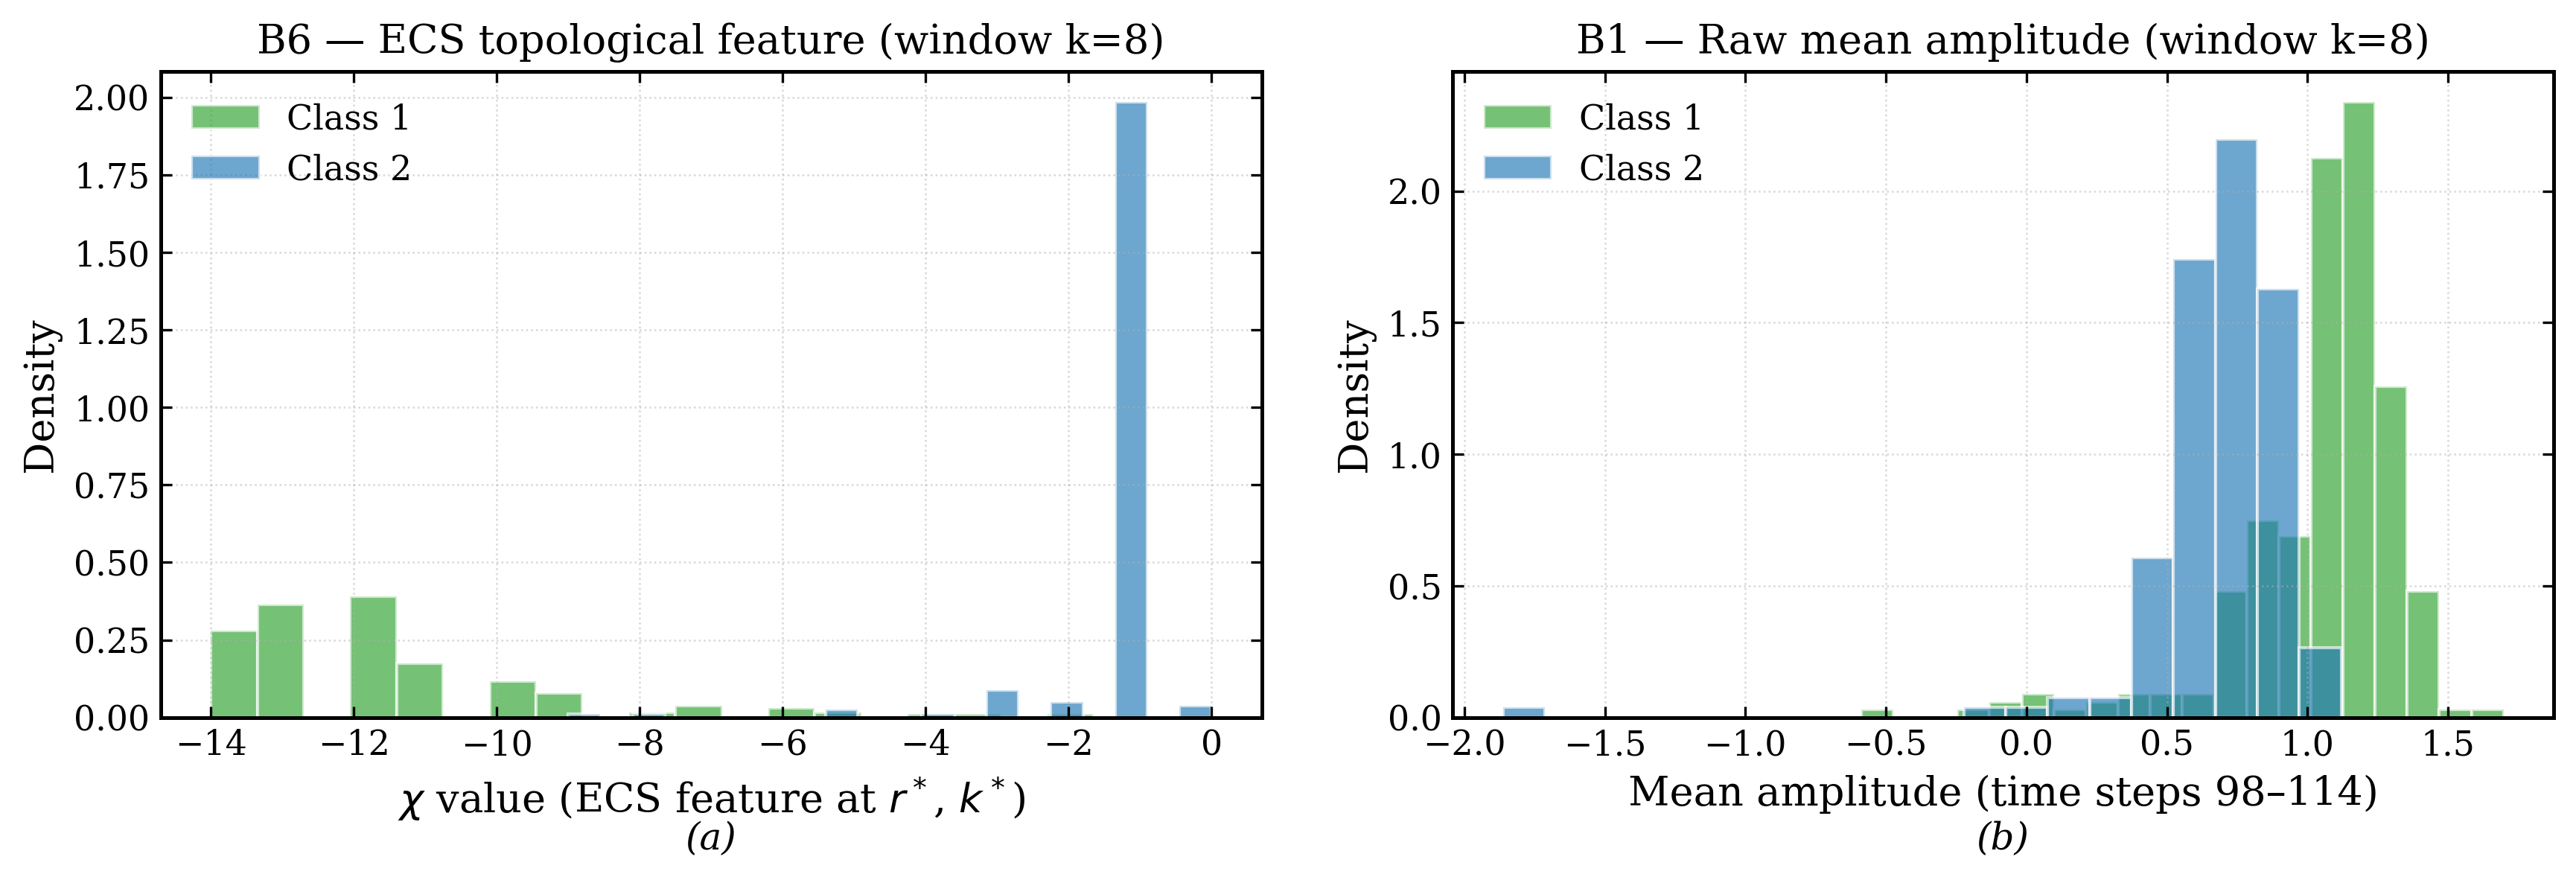

Figure saved.


In [31]:
# ============================================================
# Figure 7D — Side-by-side density: ECS feature vs mean amplitude
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)

ecs_sc_tr = X_tr_ecs[:, feat_idx] * (-1 if res_sf.get('flip', False) else 1)

ax_l = axes[0]
ax_l.hist(ecs_sc_tr[y_bin_tr == 0], bins=20, alpha=0.65, density=True,
          color="tab:green", edgecolor="white", lw=0.4,
          label=f"Class {labels[0]}")
ax_l.hist(ecs_sc_tr[y_bin_tr == 1], bins=20, alpha=0.65, density=True,
          color="tab:blue", edgecolor="white", lw=0.4,
          label=f"Class {labels[1]}")
ax_l.set_xlabel(r"$\chi$ value (ECS feature at $r^*$, $k^*$)")
ax_l.set_ylabel("Density")
ax_l.set_title(f"B6 — ECS topological feature (window k={best_k_val})")
ax_l.legend()
ax_l.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_l.text(0.5, -0.16, "(a)", transform=ax_l.transAxes,
          ha="center", va="top", fontsize=12, fontstyle="italic")

ax_r = axes[1]
ax_r.hist(F_tr_raw[y_bin_tr == 0, 0], bins=20, alpha=0.65, density=True,
          color="tab:green", edgecolor="white", lw=0.4,
          label=f"Class {labels[0]}")
ax_r.hist(F_tr_raw[y_bin_tr == 1, 0], bins=20, alpha=0.65, density=True,
          color="tab:blue", edgecolor="white", lw=0.4,
          label=f"Class {labels[1]}")
ax_r.set_xlabel(f"Mean amplitude (time steps {raw_start}–{raw_end})")
ax_r.set_ylabel("Density")
ax_r.set_title(f"B1 — Raw mean amplitude (window k={best_k_val})")
ax_r.legend()
ax_r.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_r.text(0.5, -0.16, "(b)", transform=ax_r.transAxes,
          ha="center", va="top", fontsize=12, fontstyle="italic")

fig.tight_layout(pad=2.0)
fig.savefig(f"{Dataset_name}_ablation_density.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Part 8 — Baseline Comparison

Evaluates 1-NN DTW, Shapelet Transform, ROCKET, MiniROCKET, and HIVE-COTE V2
across all five datasets under identical UCR train/test splits.

> **Note:** HIVE-COTE V2 and InceptionTime are very slow. Expect several hours
> per dataset for HIVE-COTE V2. Comment out if time is limited.


In [32]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)
from aeon.datasets import load_classification
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.classification.shapelet_based import ShapeletTransformClassifier
from aeon.classification.convolution_based import RocketClassifier, MiniRocketClassifier
from aeon.classification.hybrid import HIVECOTEV2
from aeon.classification.deep_learning import InceptionTimeClassifier

# ================================================================
# Dataset configurations — all five datasets
# ================================================================
DATASET_CONFIGS = {
    "ECG5000": {
        "aeon_name"   : "ECG5000",
        "keep_classes": ("1", "2"),
        "merge_map"   : None,
        "pos_label"   : "1",
    },
    "TwoLeadECG": {
        "aeon_name"   : "TwoLeadECG",
        "keep_classes": None,
        "merge_map"   : None,
        "pos_label"   : None,
    },
    "ECG200": {
        "aeon_name"   : "ECG200",
        "keep_classes": None,
        "merge_map"   : None,
        "pos_label"   : None,
    },
    "ECGFiveDays": {
        "aeon_name"   : "ECGFiveDays",
        "keep_classes": None,
        "merge_map"   : None,
        "pos_label"   : None,
    },
    "Epilepsy2": {
        "aeon_name"   : "EpilepticSeizures",
        "keep_classes": None,
        "merge_map"   : None,
        "pos_label"   : None,
    },
}

# ================================================================
# Classifiers
# Expected wall-clock times for HIVE-COTE V2 on CPU:
#   ECG5000 (469 train): 4-8 hours
#   TwoLeadECG (23 train): 5-15 minutes
#   ECG200 (100 train): 30-60 minutes
#   ECGFiveDays (23 train): 10-20 minutes
#   Epilepsy2 (80 train): 30-90 minutes
# ================================================================
def make_classifiers():
    clfs = {
        "1-NN DTW": KNeighborsTimeSeriesClassifier(
            n_neighbors=1, distance="dtw",
        ),
        "Shapelet Transform": ShapeletTransformClassifier(
            random_state=42,
        ),
        "ROCKET": RocketClassifier(
            n_kernels=10000, random_state=42,
        ),
        "MiniROCKET": MiniRocketClassifier(
            n_kernels=10000, random_state=42,
        ),
        "HIVE-COTE V2": HIVECOTEV2(
            time_limit_in_minutes=0,   # 0 = no time limit
            random_state=42,
            verbose=1,
        ),
    }
    try:
        clfs["InceptionTime"] = InceptionTimeClassifier(
            n_epochs=1500, n_classifiers=5, random_state=42,
        )
    except (ImportError, ModuleNotFoundError):
        print("WARNING: InceptionTime skipped — tensorflow not installed.")
    return clfs

In [33]:
# ================================================================
# Load and preprocess
# ================================================================
def load_dataset(cfg):
    X_tr_b, y_tr_b = load_classification(
        cfg["aeon_name"], split="train",
        load_equal_length=True, load_no_missing=True,
    )
    X_te_b, y_te_b = load_classification(
        cfg["aeon_name"], split="test",
        load_equal_length=True, load_no_missing=True,
    )
    X_tr_b = np.asarray(X_tr_b); y_tr_b = np.asarray(y_tr_b)
    X_te_b = np.asarray(X_te_b); y_te_b = np.asarray(y_te_b)

    if cfg["keep_classes"] is not None:
        m_tr = np.isin(y_tr_b, cfg["keep_classes"])
        m_te = np.isin(y_te_b, cfg["keep_classes"])
        X_tr_b, y_tr_b = X_tr_b[m_tr], y_tr_b[m_tr]
        X_te_b, y_te_b = X_te_b[m_te], y_te_b[m_te]

    if cfg["merge_map"] is not None:
        m = cfg["merge_map"]
        y_tr_b = np.array([m[str(c)] for c in y_tr_b])
        y_te_b = np.array([m[str(c)] for c in y_te_b])

    return X_tr_b, y_tr_b, X_te_b, y_te_b


# ================================================================
# Evaluate — AUC polarity flip + corrected confusion matrix
# ================================================================
def evaluate_baseline(clf, X_te_b, y_te_b, pos_label):
    y_pred  = clf.predict(X_te_b)
    y_proba = clf.predict_proba(X_te_b)
    classes = list(clf.classes_)

    if pos_label is None:
        pos_label = sorted(classes)[0]

    neg_label = [c for c in classes if c != pos_label][0]
    pos_idx   = classes.index(pos_label)

    auc = roc_auc_score(y_te_b, y_proba[:, pos_idx])
    if auc < 0.5:
        auc      = 1.0 - auc
        eff_pos  = neg_label
        eff_neg  = pos_label
    else:
        eff_pos  = pos_label
        eff_neg  = neg_label

    acc  = accuracy_score(y_te_b, y_pred)
    prec = precision_score(y_te_b, y_pred, pos_label=eff_pos, zero_division=0)
    rec  = recall_score   (y_te_b, y_pred, pos_label=eff_pos, zero_division=0)
    f1   = f1_score       (y_te_b, y_pred, pos_label=eff_pos, zero_division=0)

    cm = confusion_matrix(y_te_b, y_pred, labels=[eff_pos, eff_neg])
    tp, fn, fp, tn = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dict(
        AUC=auc, Accuracy=acc, Precision=prec,
        Recall=rec, Specificity=spec, F1=f1,
        TP=int(tp), FN=int(fn), FP=int(fp), TN=int(tn),
        polarity_flipped=(eff_pos != pos_label),
    )

In [34]:
# ================================================================
# Main baseline evaluation loop
# ================================================================
all_results = {}

for ds_name, cfg in DATASET_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name}")
    print("="*60)

    try:
        X_tr_b, y_tr_b, X_te_b, y_te_b = load_dataset(cfg)
    except Exception as e:
        print(f"  [LOAD ERROR] {e}"); continue

    print(f"  Train: {X_tr_b.shape}  Test: {X_te_b.shape}")
    print(f"  Classes: {np.unique(y_tr_b).tolist()}")

    pos_label = cfg["pos_label"] or sorted(np.unique(y_tr_b).tolist())[0]
    print(f"  Positive class: '{pos_label}'")

    all_results[ds_name] = {}
    classifiers = make_classifiers()

    for clf_name, clf in classifiers.items():
        print(f"\n  [{clf_name}] training...", end=" ", flush=True)
        try:
            clf.fit(X_tr_b, y_tr_b)
            m = evaluate_baseline(clf, X_te_b, y_te_b, pos_label)
            all_results[ds_name][clf_name] = m
            flip = " [polarity flipped]" if m["polarity_flipped"] else ""
            print(
                f"Acc={m['Accuracy']:.4f}  "
                f"AUC={m['AUC']:.4f}  "
                f"F1={m['F1']:.4f}{flip}"
            )
        except Exception as e:
            print(f"[ERROR] {e}")


Dataset: ECG5000
  Train: (469, 1, 140)  Test: (4217, 1, 140)
  Classes: ['1', '2']
  Positive class: '1'

  [1-NN DTW] training... 

KeyboardInterrupt: 

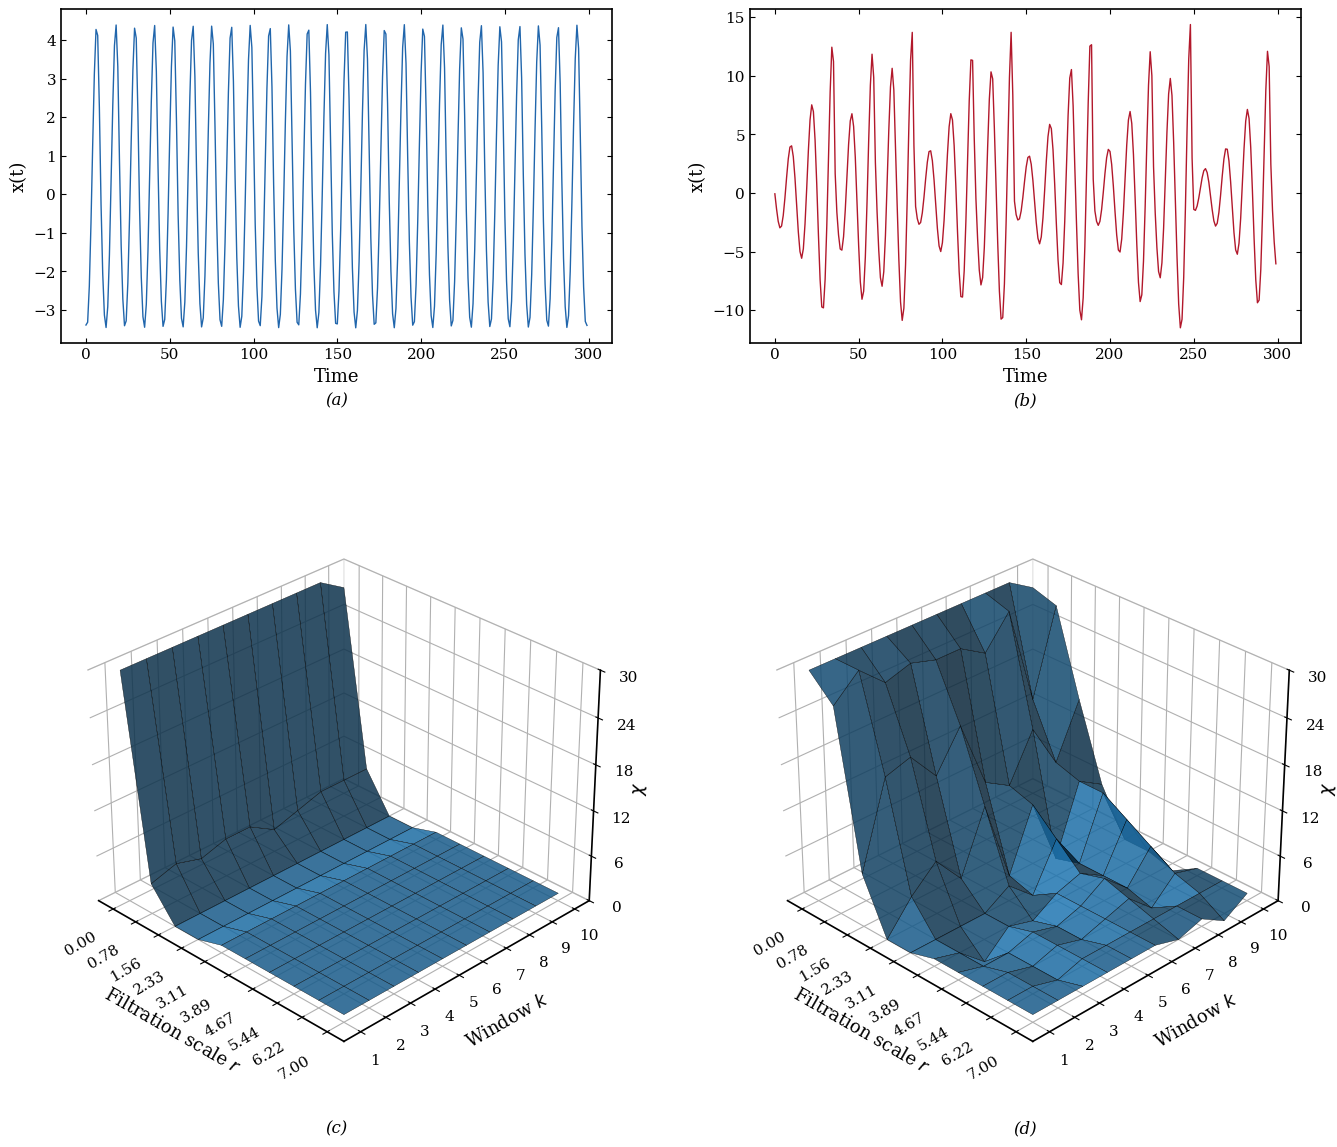

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FixedLocator, FixedFormatter, MaxNLocator
from gudhi import AlphaComplex
from numba import njit

# ============================================================
# PARAMETERS
DIM = 3
DELAY = 1

SCALES = np.linspace(1e-6, 7.0, 10)
GRID_NX = 10
GRID_NY = 10

T = 150.0
DT = 0.5
TRANSIENT_TIME = 60.0
# ============================================================


# ============================================================
# Rössler system
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]


def generate_rossler(c, T, dt, transient):
    T_total = T + transient
    t_eval  = np.arange(0, T_total, dt)
    sol = solve_ivp(
        rossler,
        [0, T_total],
        y0=[1.0, 1.0, 1.0],
        args=(0.2, 0.2, c),
        t_eval=t_eval,
        rtol=1e-9, atol=1e-9
    )
    discard = int(transient / dt)
    return sol.y[:, discard:]


# ============================================================
# Takens embedding
def time_delay_embedding(ts, dim=3, delay=1):
    ts = np.asarray(ts)
    N  = len(ts) - (dim - 1) * delay
    return np.column_stack([ts[i:i+N] for i in range(0, dim*delay, delay)])


# ============================================================
# Euler characteristic curve
@njit
def compute_chi_curve(filtration_vals, filtration_dims, scales):
    order  = np.argsort(filtration_vals)
    s_vals = filtration_vals[order]
    s_dims = filtration_dims[order]
    chi = 0
    ptr = 0
    out = np.zeros(len(scales), dtype=np.int64)
    for i, r in enumerate(scales):
        thr = r * r
        while ptr < len(s_vals) and s_vals[ptr] <= thr:
            chi += 1 if s_dims[ptr] % 2 == 0 else -1
            ptr += 1
        out[i] = chi
    return out


# ============================================================
# ECS construction (NON-OVERLAPPING WINDOWS) — unchanged
def build_ecs_scatter(ts, dim, delay, scales):
    pc     = time_delay_embedding(ts, dim, delay)
    M      = pc.shape[0]
    STEP   = M // 10 + 1
    WINDOW = 10

    x_vals, y_vals, z_vals = [], [], []
    window_index = 1

    for k in range(WINDOW):
        start = k * STEP
        block = pc[start:] if k == WINDOW - 1 else pc[start:start + STEP]

        st   = AlphaComplex(points=block.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        vals = np.array([f          for _, f in filt], dtype=np.float64)
        dims = np.array([len(s) - 1 for s, _ in filt], dtype=np.int64)

        chi_curve = compute_chi_curve(vals, dims, scales)

        for r, chi in zip(scales, chi_curve):
            x_vals.append(r)
            y_vals.append(window_index)
            z_vals.append(chi)

        window_index += 1

    return np.array(x_vals), np.array(y_vals), np.array(z_vals)


# ============================================================
# ECS → grid — unchanged
def ecs_to_grid(x, y, z, nx=10, ny=10):
    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x, y), z, (XI, YI), method="linear")
    if np.any(np.isnan(ZI)):
        ZI = griddata((x, y), z, (XI, YI), method="nearest")
    return XI, YI, ZI


# ============================================================
# ECS surface plot helper — unchanged
def plot_ecs_surface(ax3d, XI, YI, ZI, scales, window=10):

    ax3d.plot_surface(
        XI, YI, ZI,
        linewidth   = 0.25,
        edgecolor   = "black",
        antialiased = True,
        alpha       = 0.85,
        shade       = True,
    )

    ax3d.view_init(elev=30, azim=-45)

    ax3d.set_xlabel(r"Filtration scale $r$",  labelpad=14, fontsize=13)
    ax3d.set_ylabel(r"Window $k$", labelpad=8,  fontsize=13)
    ax3d.set_zlabel(r"$\chi$",     labelpad=-2,  fontsize=13)

    ax3d.xaxis.set_major_locator(FixedLocator(scales))
    ax3d.xaxis.set_major_formatter(FixedFormatter([f"{s:.2f}" for s in scales]))
    for tick in ax3d.xaxis.get_majorticklabels():
        tick.set_fontsize(6)
        tick.set_rotation(30)
        tick.set_ha("right")
        tick.set_verticalalignment("top")

    win_ticks = np.arange(1, window + 1)
    ax3d.set_yticks(win_ticks)
    ax3d.set_yticklabels([str(w) for w in win_ticks], fontsize=6)

    ax3d.set_zlim(0, 30)
    ax3d.zaxis.set_major_locator(FixedLocator([0, 6, 12, 18, 24, 30]))
    ax3d.zaxis.set_major_formatter(FixedFormatter(["0", "6", "12", "18", "24", "30"]))

    ax3d.tick_params(labelsize=11)

    ax3d.xaxis.pane.fill = False
    ax3d.yaxis.pane.fill = False
    ax3d.zaxis.pane.fill = False
    ax3d.xaxis.pane.set_edgecolor("#cccccc")
    ax3d.yaxis.pane.set_edgecolor("#cccccc")
    ax3d.zaxis.pane.set_edgecolor("#cccccc")
    ax3d.grid(True, linestyle=":", linewidth=0.4, alpha=0.6)


# ============================================================
# MAIN
if __name__ == "__main__":

    sol1 = generate_rossler(c=2.3, T=T, dt=DT, transient=TRANSIENT_TIME)
    sol2 = generate_rossler(c=7.3, T=T, dt=DT, transient=TRANSIENT_TIME)

    ts1 = sol1[0]
    ts2 = sol2[0]

    x1, y1, z1 = build_ecs_scatter(ts1, DIM, DELAY, SCALES)
    x2, y2, z2 = build_ecs_scatter(ts2, DIM, DELAY, SCALES)

    XI1, YI1, ZI1 = ecs_to_grid(x1, y1, z1, GRID_NX, GRID_NY)
    XI2, YI2, ZI2 = ecs_to_grid(x2, y2, z2, GRID_NX, GRID_NY)

    # ------------------------------------------------------------------
    # 2-row GridSpec: time-series (top) + ECS surfaces (bottom)
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(16, 14))

    gs = GridSpec(
        2, 2,
        figure        = fig,
        height_ratios = [2, 3.5],   # ts : ECS
        hspace        = 0.35,
        wspace        = 0.25,
    )

    COL_P = "#2166AC"
    COL_C = "#B2182B"

    def subfig_label(ax, letter):
        pos = ax.get_position()
        fig.text(
            pos.x0 + pos.width * 0.5,
            pos.y0 - 0.035,
            f"({letter})",
            ha="center", va="top",
            fontsize=12, fontstyle="italic"
        )

    # ── (a) Time series — periodic
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.plot(ts1, color=COL_P, linewidth=1)
    ax_a.set_xlabel("Time", fontsize=13)
    ax_a.set_ylabel("x(t)", fontsize=13)
    ax_a.tick_params(direction="in")

    # ── (b) Time series — chaotic
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.plot(ts2, color=COL_C, linewidth=1)
    ax_b.set_xlabel("Time", fontsize=13)
    ax_b.set_ylabel("x(t)", fontsize=13)
    ax_b.tick_params(direction="in")

    # ── (c) ECS surface — periodic
    ax_c = fig.add_subplot(gs[1, 0], projection="3d")
    plot_ecs_surface(ax_c, XI1, YI1, ZI1, SCALES, window=10)

    # ── (d) ECS surface — chaotic
    ax_d = fig.add_subplot(gs[1, 1], projection="3d")
    plot_ecs_surface(ax_d, XI2, YI2, ZI2, SCALES, window=10)

    for ax, letter in [(ax_a, "a"), (ax_b, "b"),
                       (ax_c, "c"), (ax_d, "d")]:
        subfig_label(ax, letter)

    plt.savefig("rossler_ecs.pdf", dpi=600, bbox_inches="tight")
    plt.show()

Simulating...
Computing ECS...
Generating noisy ECS samples...
Computing L1 distances...
Saved rossler_ecs_l1.pdf and rossler_ecs_l1.png


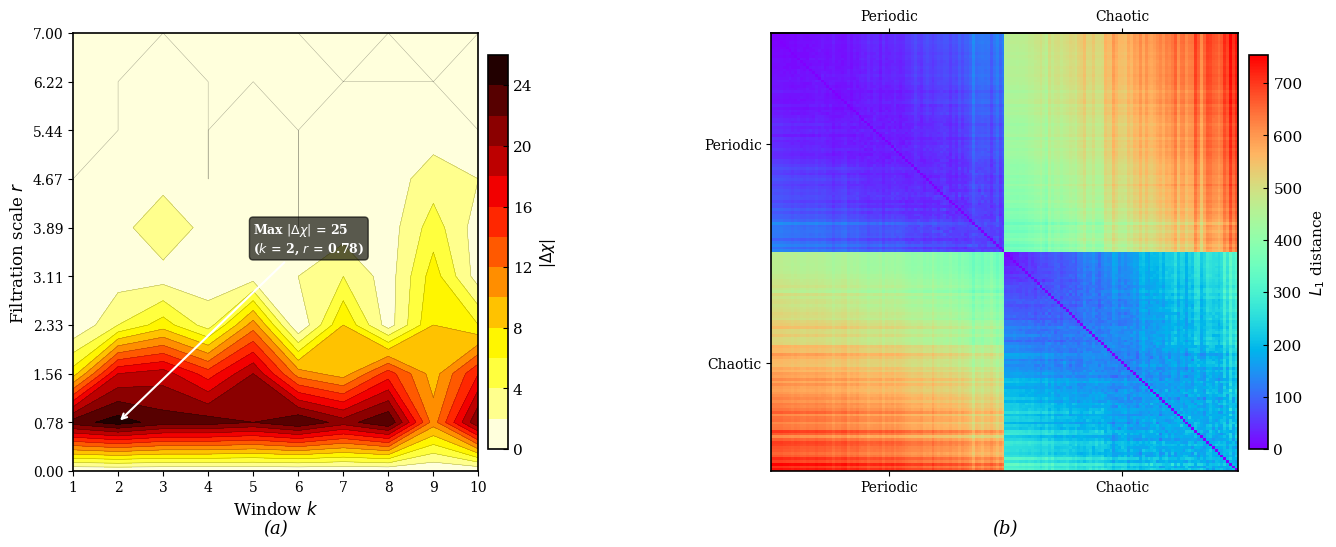

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from gudhi import AlphaComplex
from numba import njit

# ============================================================
# PARAMETERS
# ============================================================
DIM = 3
DELAY = 1
SCALES = np.linspace(1e-6, 7.0, 10)

GRID_NX = 10
GRID_NY = 10

T = 150.0
DT = 0.5
TRANSIENT_TIME = 60.0

N_NOISE = 1
NOISE_LEVELS = np.linspace(0.0, 0.10, 80)

WINDOW = 10

# ============================================================
# RÖSSLER SYSTEM
# ============================================================
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]

def generate_rossler(c, T, dt, transient):
    T_total = T + transient
    t_eval = np.arange(0, T_total, dt)

    sol = solve_ivp(
        rossler,
        [0, T_total],
        y0=[1.0, 1.0, 1.0],
        args=(0.2, 0.2, c),
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-9
    )

    discard = int(transient / dt)
    return sol.y[:, discard:]

# ============================================================
# TAKENS EMBEDDING
# ============================================================
def time_delay_embedding(ts, dim=3, delay=1):
    ts = np.asarray(ts)
    N = len(ts) - (dim - 1) * delay
    return np.column_stack(
        [ts[i:i+N] for i in range(0, dim*delay, delay)]
    )

# ============================================================
# EULER CHARACTERISTIC CURVE
# ============================================================
@njit
def compute_chi_curve(vals, dims, scales):
    order = np.argsort(vals)
    vals = vals[order]
    dims = dims[order]

    chi = 0
    ptr = 0
    out = np.zeros(len(scales), dtype=np.int64)

    for i, r in enumerate(scales):
        thr = r * r
        while ptr < len(vals) and vals[ptr] <= thr:
            if dims[ptr] % 2 == 0:
                chi += 1
            else:
                chi -= 1
            ptr += 1
        out[i] = chi

    return out

# ============================================================
# ECS SCATTER (WINDOW FIX APPLIED HERE)
# ============================================================
def build_ecs_scatter(ts, dim, delay, scales):
    pc = time_delay_embedding(ts, dim, delay)
    M = pc.shape[0]

    WINDOW_LOCAL = 10
    w = M // WINDOW_LOCAL + 1   # <-- required step rule

    x_vals = []
    y_vals = []
    z_vals = []

    for k in range(WINDOW_LOCAL):
        start = k * w
        if k < WINDOW_LOCAL - 1:
            block = pc[start:start + w]
        else:
            block = pc[start:]   # last block gets remainder

        if len(block) < 3:
            continue

        st = AlphaComplex(points=block.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if len(filt) == 0:
            continue

        vals = np.array([f for _, f in filt], dtype=np.float64)
        dims = np.array([len(s) - 1 for s, _ in filt], dtype=np.int64)

        chi_curve = compute_chi_curve(vals, dims, scales)

        for r, chi in zip(scales, chi_curve):
            x_vals.append(r)
            y_vals.append(k + 1)
            z_vals.append(chi)

    return np.array(x_vals), np.array(y_vals), np.array(z_vals)

# ============================================================
# ECS → GRID
# ============================================================
def ecs_to_grid(x, y, z, nx=10, ny=10):
    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)
    XI, YI = np.meshgrid(xi, yi)

    ZI = griddata((x, y), z, (XI, YI), method="linear")
    if np.any(np.isnan(ZI)):
        ZI = griddata((x, y), z, (XI, YI), method="nearest")

    return XI, YI, ZI

# ============================================================
# ECS VECTOR
# ============================================================
def ecs_flat(ts, noise_std):
    noise = noise_std * np.random.randn(len(ts))
    xv, yv, zv = build_ecs_scatter(ts + noise, DIM, DELAY, SCALES)
    _, _, ZI = ecs_to_grid(xv, yv, zv, GRID_NX, GRID_NY)
    return ZI.flatten()

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    print("Simulating...")

    sol1 = generate_rossler(2.3, T, DT, TRANSIENT_TIME)
    sol2 = generate_rossler(7.3, T, DT, TRANSIENT_TIME)

    ts1 = sol1[0]
    ts2 = sol2[0]

    print("Computing ECS...")

    x1, y1, z1 = build_ecs_scatter(ts1, DIM, DELAY, SCALES)
    x2, y2, z2 = build_ecs_scatter(ts2, DIM, DELAY, SCALES)

    _, _, ZI1 = ecs_to_grid(x1, y1, z1)
    _, _, ZI2 = ecs_to_grid(x2, y2, z2)

    diff = np.abs(ZI2 - ZI1)

    # ========================================================
    # BUILD NOISY ECS SAMPLES
    # ========================================================

    print("Generating noisy ECS samples...")

    np.random.seed(42)

    samples_P = []
    samples_C = []

    for nl in NOISE_LEVELS:

        sigP = (np.max(ts1) - np.min(ts1)) * nl
        sigC = (np.max(ts2) - np.min(ts2)) * nl

        for _ in range(N_NOISE):

            samples_P.append(ecs_flat(ts1, sigP))
            samples_C.append(ecs_flat(ts2, sigC))

    all_samples = np.array(samples_P + samples_C)

    print("Computing L1 distances...")

    DM = cdist(all_samples, all_samples, metric="cityblock")

    n_P = len(samples_P)
    n_C = len(samples_C)

    # ========================================================
    # PREPARE AXES VARIABLES
    # ========================================================

    n_windows = WINDOW
    k_vals = np.arange(1, WINDOW + 1)
    r_vals = SCALES
    KK, RR = np.meshgrid(k_vals, r_vals)

    # ========================================================
    # FIGURE
    # ========================================================

    fig, (ax_a, ax_b) = plt.subplots(
        1, 2,
        figsize=(14, 6),
        gridspec_kw={"width_ratios": [1, 1.15]}
    )

    fig.subplots_adjust(
        wspace=0.40,
        left=0.07,
        right=0.97,
        top=0.93,
        bottom=0.20
    )

    # ============================================================
    # PANEL (a) : |ECS_chaotic − ECS_periodic|
    # ============================================================

    levels = 15

    cf = ax_a.contourf(
        KK, RR, diff.T,
        levels=levels,
        cmap="hot_r"
    )

    ax_a.contour(
        KK, RR, diff.T,
        levels=levels,
        colors="k",
        linewidths=0.3,
        alpha=0.4
    )

    ax_a.set_xlabel(r"Window $k$", fontsize=12)
    ax_a.set_ylabel(r"Filtration scale $r$", fontsize=12)

    ax_a.set_xticks(np.arange(1, n_windows + 1))

    # force exact scale ticks
    ax_a.set_yticks(SCALES)
    ax_a.set_yticklabels([f"{s:.2f}" for s in SCALES])

    ax_a.tick_params(
        labelsize=10,
        direction="out",
        top=False,
        right=False
    )

    cbar_a = fig.colorbar(cf, ax=ax_a, shrink=0.9, pad=0.02)
    cbar_a.set_label(r"$|\Delta\chi|$", fontsize=11)

    # ------------------------------------------------------------
    # Maximum difference annotation
    # ------------------------------------------------------------

    idx_max = np.unravel_index(np.argmax(diff), diff.shape)

    k_max = k_vals[idx_max[0]]
    r_max = r_vals[idx_max[1]]

    ax_a.annotate(
        f"Max $|\\Delta\\chi|$ = {diff.max():.0f}\n"
        f"($k$ = {k_max:.0f}, $r$ = {r_max:.2f})",
        xy=(k_max, r_max),
        xytext=(n_windows/2, (SCALES.min() + SCALES.max())/2),
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="black",
            alpha=0.65
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="white",
            lw=1.5
        )
    )

    # ============================================================
    # PANEL (b) : pairwise L1 ECS distances
    # ============================================================

    im = ax_b.imshow(
        DM,
        cmap="rainbow",
        aspect="auto",
        interpolation="nearest"
    )

    ax_b.tick_params(
        labelsize=10,
        direction="out",
        top=False,
        right=False,
        labeltop=False,
        labelright=False
    )

    cbar_b = fig.colorbar(im, ax=ax_b, shrink=0.9, pad=0.02)
    cbar_b.set_label(r"$L_1$ distance", fontsize=11)

    # ------------------------------------------------------------
    # Periodic / Chaotic labels
    # ------------------------------------------------------------

    mid_P = n_P / 2
    mid_C = n_P + n_C / 2

    # bottom axis
    ax_b.set_xticks([mid_P, mid_C])
    ax_b.set_xticklabels(["Periodic", "Chaotic"], fontsize=10)

    # top axis
    ax_b2 = ax_b.secondary_xaxis("top")
    ax_b2.set_xticks([mid_P, mid_C])
    ax_b2.set_xticklabels(["Periodic", "Chaotic"], fontsize=10)
    ax_b2.tick_params(direction="out", labelsize=10)

    # left axis
    ax_b.set_yticks([mid_P, mid_C])
    ax_b.set_yticklabels(["Periodic", "Chaotic"], fontsize=10)

    # ============================================================
    # Subfigure labels
    # ============================================================

    fig.canvas.draw()

    for ax, letter in [(ax_a, "a"), (ax_b, "b")]:

        pos = ax.get_position()

        fig.text(
            pos.x0 + pos.width * 0.5,
            pos.y0 - 0.08,
            f"({letter})",
            ha="center",
            va="top",
            fontsize=13,
            fontstyle="italic"
        )

    # ============================================================
    # Save and show
    # ============================================================

    plt.savefig("rossler_ecs_l1.pdf", dpi=600, bbox_inches="tight")
    plt.savefig("rossler_ecs_l1.png", dpi=200, bbox_inches="tight")

    print("Saved rossler_ecs_l1.pdf and rossler_ecs_l1.png")

    plt.show()